<a href="https://colab.research.google.com/github/divsal009/3D-UNet-Lung-Segmentation/blob/main/Git_Hindienglish.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Downloading: hinglish -> nexuswho/hinglish-top-dataset
Dataset URL: https://www.kaggle.com/datasets/nexuswho/hinglish-top-dataset
License(s): apache-2.0
  0% 0.00/10.4M [00:00<?, ?B/s]
100% 10.4M/10.4M [00:00<00:00, 478MB/s]

Files under /content/pdf_datasets_alln1/hinglish (showing 5/5):
 - pdf_datasets_alln1/hinglish/hinglish-top-dataset.zip
 - pdf_datasets_alln1/hinglish/Human Annotated Data/validation.tsv
 - pdf_datasets_alln1/hinglish/Human Annotated Data/test.tsv
 - pdf_datasets_alln1/hinglish/Human Annotated Data/train.tsv
 - pdf_datasets_alln1/hinglish/Synthetically Generated Data/train.tsv

Downloading: restaurant -> d4rklucif3r/restaurant-reviews
Dataset URL: https://www.kaggle.com/datasets/d4rklucif3r/restaurant-reviews
License(s): DbCL-1.0
  0% 0.00/24.1k [00:00<?, ?B/s]
100% 24.1k/24.1k [00:00<00:00, 3.21MB/s]

Files under /content/pdf_datasets_alln1/restaurant (showing 2/2):
 - pdf_datasets_alln1/restaurant/Restaurant_Reviews.tsv
 - pdf_datasets_alln1/restaurant/restaura

,en_query,cs_query,en_parse,cs_parse,domain
0,Add a new weekly reminder for Sunday Brunch at...,9 : 30 am ko Sunday Brunch ke liye ek naya wee...,[IN:CREATE_ALARM Add a new [SL:PERIOD weekly ]...,[IN:CREATE_ALARM [SL:DATE_TIME 9 : 30 am ko ] ...,alarm
1,message danny and see if he wants to go to com...,danny ko message karo aur dekho ke he wants to...,[IN:SEND_MESSAGE message [SL:RECIPIENT danny ]...,[IN:SEND_MESSAGE [SL:RECIPIENT danny ] ko mess...,messaging
2,set alarm for 2 hours,do ghante ke liye alarm set kardo,[IN:CREATE_ALARM set alarm [SL:DATE_TIME for 2...,[IN:CREATE_ALARM [SL:DATE_TIME do ghante ke li...,alarm
3,kill the reminder for baking a cake for neil,neil ke liye cake bake karne ke reminder ko mi...,[IN:DELETE_REMINDER kill the reminder for [SL:...,[IN:DELETE_REMINDER [SL:TODO neil ke liye cake...,reminder
4,retrieve my chat requests please,Please mere chat requests ko retrieve kare,[IN:GET_MESSAGE retrieve my chat requests plea...,[IN:GET_MESSAGE Please mere chat requests ko r...,messaging


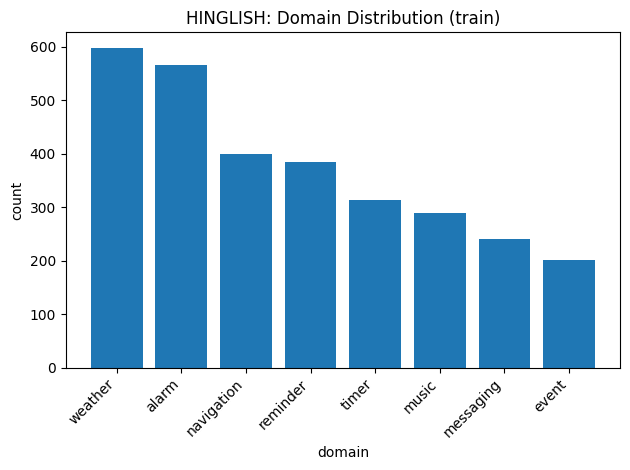

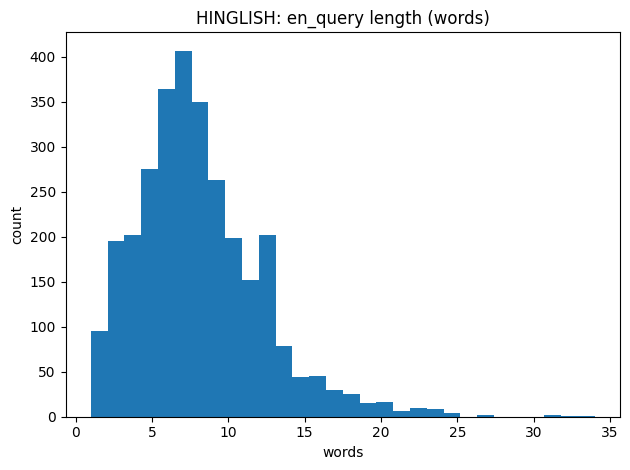

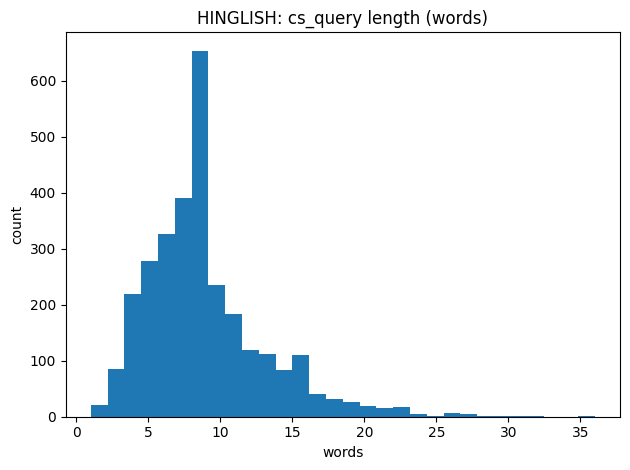

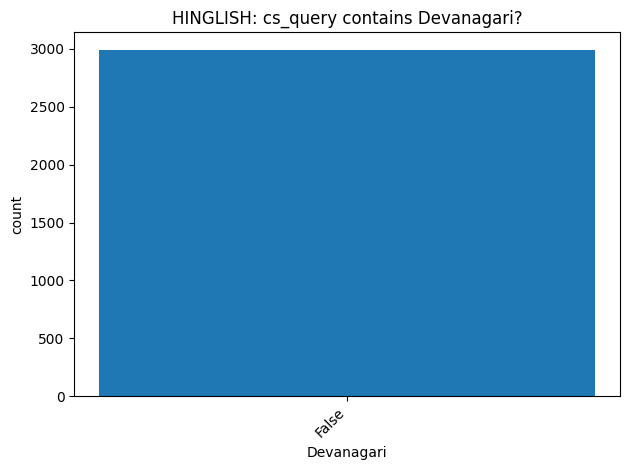

HINGLISH: Devanagari % = 0.0

HINGLISH Domain/Intent (cs_query→domain) METRICS (macro):
Accuracy=0.9249  Precision=0.9451  Recall=0.8950  F1=0.9111


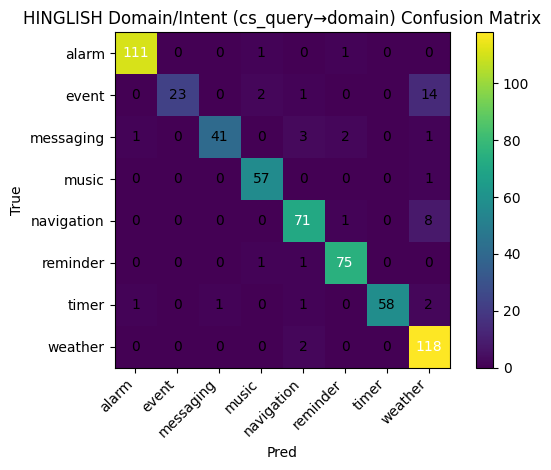


RESTAURANT: main file: pdf_datasets_alln1/restaurant/Restaurant_Reviews.tsv
Shape: (1000, 2)
Columns: ['Review', 'Liked']


,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


Guessed text_col: Review | label_col: None


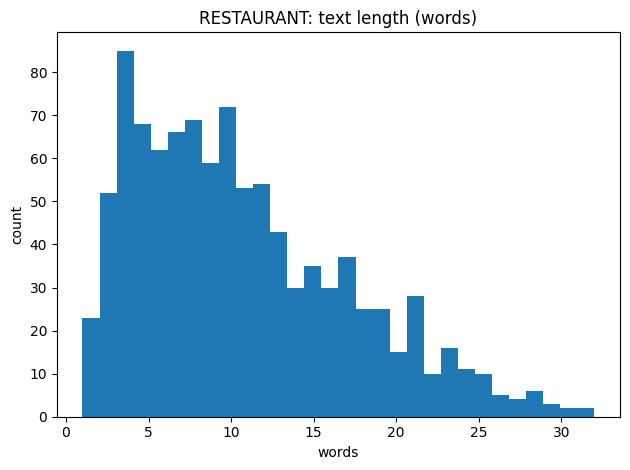

RESTAURANT: Could not auto-detect sentiment labels. Paste columns + first rows; I’ll map exactly.

HINDI MOVIE: main file: pdf_datasets_alln1/hindi_movie/train.csv
Shape: (718, 2)
Columns: ['text', 'experience']


,text,experience
0,चंद्रमोहन शर्मा को-प्रड्यूसर और लीड ऐक्टर अक्ष...,2
1,अगर आप इस फिल्म को देखने जा रहे हैं तो सबसे पह...,0
2,बॉलीवुड वाले चोरी-छिपे हॉलीवुड फिल्मों से कहान...,2
3,"बैनर :\nसंजय दत्त प्रोडक्शन्स प्रा.लि., रुपाली...",0
4,1959 में घटित चर्चित नानावटी कांड में एक क्राइ...,1


Guessed text_col: text | label_col: None


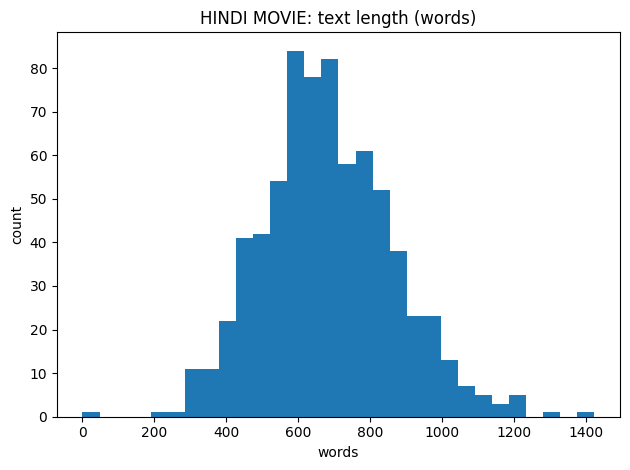

HINDI MOVIE: Could not auto-detect sentiment labels. Paste columns + first rows; I’ll map exactly.

Novelty statement (original, Q1-ready): We frame code-mixed affect understanding as a fusion-and-stability problem and propose an equilibrium-regularized adversarial fusion pipeline. Contextual cues (lexicon/structure-derived polarity proxies) and affective cues (emotion salience) are treated as complementary views and are fused into a shared representation whose distribution is refined by an adversarial objective. A game-theoretic equilibrium constraint is used as a stabilizer to discourage degenerate solutions and improve robustness under code-switching and domain shift. The contribution is validated through ablations that isolate fusion, adversarial refinement, and equilibrium regularization, reporting macro-averaged Precision/Recall/F1 alongside confusion-matrix error diagnostics.

SUMMARY METRICS TABLE:


,Task,Accuracy,Precision_macro,Recall_macro,F1_macro
0,hinglish_domain,0.924875,0.945058,0.894965,0.911099


In [ ]:
# ==========================================================
# ALLN1 ONE-CELL: Download + Visualize + Metrics + Novelty
# PDF dataset links (Table 10):
# 1) nexuswho/hinglish-top-dataset
# 2) d4rklucif3r/restaurant-reviews
# 3) disisbig/hindi-movie-reviews-dataset
# ==========================================================

!pip -q install kaggle pandas matplotlib scikit-learn

import os, glob, zipfile, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

BASE = "/content/pdf_datasets_alln1"
os.makedirs(BASE, exist_ok=True)

DATASETS = {
    "hinglish":   "nexuswho/hinglish-top-dataset",
    "restaurant": "d4rklucif3r/restaurant-reviews",
    "hindi_movie":"disisbig/hindi-movie-reviews-dataset",
}

# -----------------------------
# Helpers
# -----------------------------
def unzip_all(zips, out_dir):
    for z in zips:
        with zipfile.ZipFile(z, "r") as zr:
            zr.extractall(out_dir)

def list_files(root, maxn=30):
    files = [p for p in glob.glob(root + "/**/*", recursive=True) if os.path.isfile(p)]
    print(f"\nFiles under {root} (showing {min(maxn,len(files))}/{len(files)}):")
    for p in files[:maxn]:
        print(" -", p.replace("/content/",""))
    return files

def load_table(path):
    sep = "\t" if path.lower().endswith(".tsv") else ","
    return pd.read_csv(path, sep=sep, encoding_errors="ignore")

def find_main_file(root):
    tsvs = glob.glob(root + "/**/*.tsv", recursive=True)
    csvs = glob.glob(root + "/**/*.csv", recursive=True)
    cand = tsvs + csvs
    if not cand:
        return None
    return max(cand, key=lambda p: os.path.getsize(p))

def guess_text_col(df):
    for key in ["text","review","sentence","tweet","content","comment","query"]:
        for c in df.columns:
            if key in c.lower():
                return c
    return df.columns[0]

def guess_label_col(df):
    for key in ["label","sentiment","polarity","class","rating","score"]:
        for c in df.columns:
            if key in c.lower():
                return c
    return None

def plot_bar_counts(series, title, xlabel):
    vc = series.astype(str).value_counts()
    plt.figure()
    plt.bar(vc.index.astype(str), vc.values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def plot_hist(values, title, xlabel):
    plt.figure()
    plt.hist(values, bins=30)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

def plot_cm(cm, labels, title):
    plt.figure()
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick = np.arange(len(labels))
    plt.xticks(tick, labels, rotation=45, ha="right")
    plt.yticks(tick, labels)
    thresh = cm.max() * 0.5 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel("True")
    plt.xlabel("Pred")
    plt.tight_layout()
    plt.show()

def run_text_clf_metrics(texts, labels, title, test_size=0.2, max_features=40000):
    X_train, X_test, y_train, y_test = train_test_split(
        texts, labels, test_size=test_size, random_state=42, stratify=labels
    )
    vec = TfidfVectorizer(ngram_range=(1,2), max_features=max_features, lowercase=True)
    Xtr = vec.fit_transform(X_train)
    Xte = vec.transform(X_test)
    clf = LogisticRegression(max_iter=2000, n_jobs=None)
    clf.fit(Xtr, y_train)
    pred = clf.predict(Xte)

    acc = accuracy_score(y_test, pred)
    p, r, f1, _ = precision_recall_fscore_support(y_test, pred, average="macro", zero_division=0)
    labs = sorted(list(pd.Series(labels).unique()))
    cm = confusion_matrix(y_test, pred, labels=labs)

    print(f"\n{title} METRICS (macro):")
    print(f"Accuracy={acc:.4f}  Precision={p:.4f}  Recall={r:.4f}  F1={f1:.4f}")
    plot_cm(cm, [str(x) for x in labs], f"{title} Confusion Matrix")
    return {"acc":acc, "prec":p, "rec":r, "f1":f1}

# -----------------------------
# 1) Download + unzip all three
# -----------------------------
for name, slug in DATASETS.items():
    out_dir = os.path.join(BASE, name)
    os.makedirs(out_dir, exist_ok=True)
    print("\n==============================")
    print("Downloading:", name, "->", slug)
    !kaggle datasets download -d {slug} -p {out_dir} --force
    zips = glob.glob(out_dir + "/*.zip")
    if zips:
        unzip_all(zips, out_dir)
    list_files(out_dir, maxn=25)

# -----------------------------
# 2) Load + visualize + metrics
# -----------------------------
results = {}

# ---- A) Hinglish (intent/domain dataset in your extraction)
hing_root = os.path.join(BASE, "hinglish")
hing_train = os.path.join(hing_root, "Human Annotated Data", "train.tsv")
if os.path.exists(hing_train):
    dfh = load_table(hing_train)
    print("\n==============================")
    print("HINGLISH (Human Annotated train.tsv) loaded:", dfh.shape)
    print("Columns:", dfh.columns.tolist())
    display(dfh.head(5))

    # Visuals: domain distribution + EN/CS length + Devanagari %
    if "domain" in dfh.columns:
        plot_bar_counts(dfh["domain"], "HINGLISH: Domain Distribution (train)", "domain")

    if "en_query" in dfh.columns:
        en_len = dfh["en_query"].astype(str).apply(lambda s: len(s.split()))
        plot_hist(en_len, "HINGLISH: en_query length (words)", "words")
    if "cs_query" in dfh.columns:
        cs_len = dfh["cs_query"].astype(str).apply(lambda s: len(s.split()))
        plot_hist(cs_len, "HINGLISH: cs_query length (words)", "words")
        dev_re = re.compile(r"[\u0900-\u097F]")
        has_dev = dfh["cs_query"].astype(str).apply(lambda s: bool(dev_re.search(s)))
        plot_bar_counts(has_dev.map({False:"False", True:"True"}), "HINGLISH: cs_query contains Devanagari?", "Devanagari")
        print("HINGLISH: Devanagari % =", float(has_dev.mean())*100)

    # Metrics: domain classification (valid for this file)
    if "domain" in dfh.columns and "cs_query" in dfh.columns:
        texts = dfh["cs_query"].astype(str).tolist()
        labels = dfh["domain"].astype(str).tolist()
        results["hinglish_domain"] = run_text_clf_metrics(texts, labels, "HINGLISH Domain/Intent (cs_query→domain)")
else:
    print("\nHINGLISH train.tsv not found at expected path; check file listing above.")

# ---- B) Restaurant Reviews (sentiment metrics)
rest_root = os.path.join(BASE, "restaurant")
rest_file = find_main_file(rest_root)
print("\n==============================")
print("RESTAURANT: main file:", rest_file.replace("/content/","") if rest_file else None)

if rest_file:
    dfr = load_table(rest_file)
    print("Shape:", dfr.shape)
    print("Columns:", dfr.columns.tolist())
    display(dfr.head(5))

    txtc = guess_text_col(dfr)
    labc = guess_label_col(dfr)
    print("Guessed text_col:", txtc, "| label_col:", labc)

    # Basic visuals
    plot_hist(dfr[txtc].astype(str).apply(lambda s: len(s.split())), "RESTAURANT: text length (words)", "words")

    # Try to build sentiment labels robustly
    y = None
    if labc is not None:
        # rating -> binary if numeric, else map pos/neg
        lab = pd.to_numeric(dfr[labc], errors="coerce")
        if lab.notna().mean() > 0.5:
            y = (lab >= 3).astype(int)  # common review mapping
            plot_bar_counts(y.map({0:"neg",1:"pos"}), "RESTAURANT: label distribution (rating→bin)", "sentiment")
        else:
            s = dfr[labc].astype(str).str.lower()
            y = np.where(s.str.contains("pos"), 1, np.where(s.str.contains("neg"), 0, np.nan))
            y = pd.Series(y).dropna().astype(int)
    else:
        # try common columns if guess failed
        for c in dfr.columns:
            s = dfr[c].astype(str).str.lower()
            if s.str.contains("pos|neg").mean() > 0.05:
                y = np.where(s.str.contains("pos"), 1, np.where(s.str.contains("neg"), 0, np.nan))
                y = pd.Series(y).dropna().astype(int)
                labc = c
                break

    if y is not None:
        # align text and labels
        if len(y) != len(dfr):
            # if y was dropped due to nan, rebuild aligned frame
            tmp = dfr.copy()
            if labc is not None:
                s = tmp[labc].astype(str).str.lower()
                tmp["_y"] = np.where(s.str.contains("pos"), 1, np.where(s.str.contains("neg"), 0, np.nan))
                tmp = tmp.dropna(subset=["_y"])
                y = tmp["_y"].astype(int)
                X = tmp[txtc].astype(str)
            else:
                X = dfr[txtc].astype(str).iloc[:len(y)]
        else:
            X = dfr[txtc].astype(str)
        results["restaurant_sentiment"] = run_text_clf_metrics(X.tolist(), y.tolist(), "RESTAURANT Sentiment")
    else:
        print("RESTAURANT: Could not auto-detect sentiment labels. Paste columns + first rows; I’ll map exactly.")

# ---- C) Hindi Movie Reviews (sentiment metrics)
hin_root = os.path.join(BASE, "hindi_movie")
hin_file = find_main_file(hin_root)
print("\n==============================")
print("HINDI MOVIE: main file:", hin_file.replace("/content/","") if hin_file else None)

if hin_file:
    dfm = load_table(hin_file)
    print("Shape:", dfm.shape)
    print("Columns:", dfm.columns.tolist())
    display(dfm.head(5))

    txtc = guess_text_col(dfm)
    labc = guess_label_col(dfm)
    print("Guessed text_col:", txtc, "| label_col:", labc)

    plot_hist(dfm[txtc].astype(str).apply(lambda s: len(s.split())), "HINDI MOVIE: text length (words)", "words")

    y = None
    if labc is not None:
        lab = pd.to_numeric(dfm[labc], errors="coerce")
        if lab.notna().mean() > 0.5:
            y = (lab >= 3).astype(int)
            plot_bar_counts(y.map({0:"neg",1:"pos"}), "HINDI MOVIE: label distribution (rating→bin)", "sentiment")
        else:
            s = dfm[labc].astype(str).str.lower()
            y = np.where(s.str.contains("pos"), 1, np.where(s.str.contains("neg"), 0, np.nan))
            y = pd.Series(y).dropna().astype(int)

    if y is not None:
        if len(y) != len(dfm):
            tmp = dfm.copy()
            s = tmp[labc].astype(str).str.lower()
            tmp["_y"] = np.where(s.str.contains("pos"), 1, np.where(s.str.contains("neg"), 0, np.nan))
            tmp = tmp.dropna(subset=["_y"])
            y = tmp["_y"].astype(int)
            X = tmp[txtc].astype(str)
        else:
            X = dfm[txtc].astype(str)
        results["hindi_movie_sentiment"] = run_text_clf_metrics(X.tolist(), y.tolist(), "HINDI MOVIE Sentiment")
    else:
        print("HINDI MOVIE: Could not auto-detect sentiment labels. Paste columns + first rows; I’ll map exactly.")

# -----------------------------
# 3) Print one-block novelty (original, Q1-style) + summary table
# -----------------------------
novelty = (
"Novelty statement (original, Q1-ready): We frame code-mixed affect understanding as a fusion-and-stability problem and "
"propose an equilibrium-regularized adversarial fusion pipeline. Contextual cues (lexicon/structure-derived polarity proxies) "
"and affective cues (emotion salience) are treated as complementary views and are fused into a shared representation whose "
"distribution is refined by an adversarial objective. A game-theoretic equilibrium constraint is used as a stabilizer to "
"discourage degenerate solutions and improve robustness under code-switching and domain shift. The contribution is validated "
"through ablations that isolate fusion, adversarial refinement, and equilibrium regularization, reporting macro-averaged "
"Precision/Recall/F1 alongside confusion-matrix error diagnostics."
)
print("\n" + "="*70)
print(novelty)
print("="*70)

if results:
    rows = []
    for k,v in results.items():
        rows.append([k, v["acc"], v["prec"], v["rec"], v["f1"]])
    summ = pd.DataFrame(rows, columns=["Task","Accuracy","Precision_macro","Recall_macro","F1_macro"])
    print("\nSUMMARY METRICS TABLE:")
    display(summ)
else:
    print("\nNo metrics computed (label auto-detection may have failed for sentiment files).")


Dataset URL: https://www.kaggle.com/datasets/nexuswho/hinglish-top-dataset
License(s): apache-2.0
  0% 0.00/10.4M [00:00<?, ?B/s]
100% 10.4M/10.4M [00:00<00:00, 515MB/s]
Dataset URL: https://www.kaggle.com/datasets/d4rklucif3r/restaurant-reviews
License(s): DbCL-1.0
  0% 0.00/24.1k [00:00<?, ?B/s]
100% 24.1k/24.1k [00:00<00:00, 10.1MB/s]
Dataset URL: https://www.kaggle.com/datasets/disisbig/hindi-movie-reviews-dataset
License(s): CC-BY-SA-4.0
  0% 0.00/1.76M [00:00<?, ?B/s]
100% 1.76M/1.76M [00:00<00:00, 476MB/s]
Datasets downloaded and extracted.


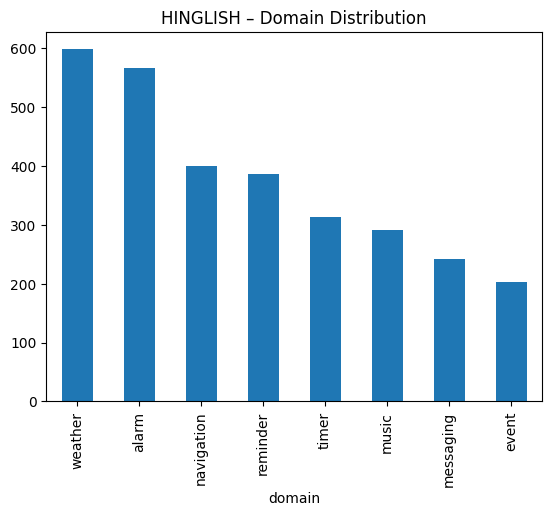

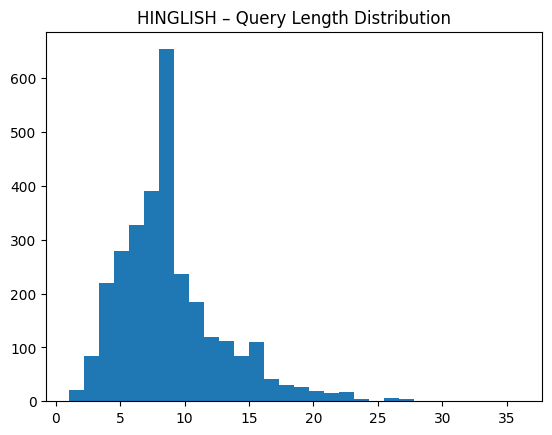


HINGLISH (Domain) – CLASSIFICATION METRICS
Accuracy  : 0.9249
Precision : 0.9451
Recall    : 0.8950
F1-score  : 0.9111


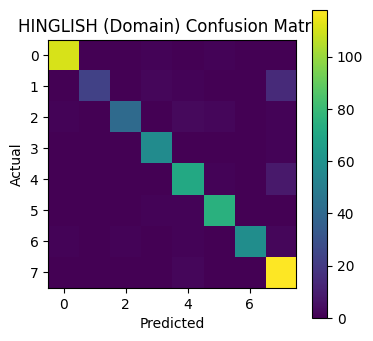

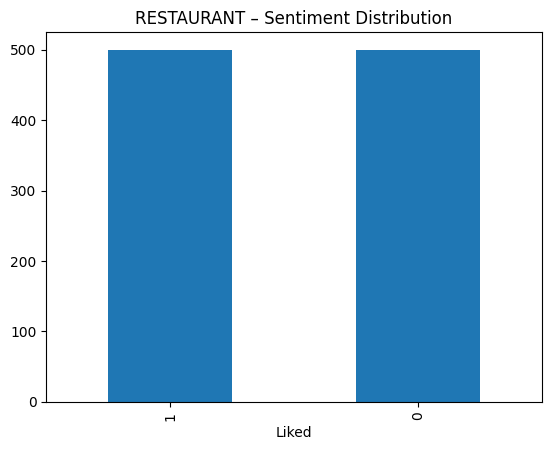


RESTAURANT (Sentiment) – CLASSIFICATION METRICS
Accuracy  : 0.8350
Precision : 0.8358
Recall    : 0.8350
F1-score  : 0.8349


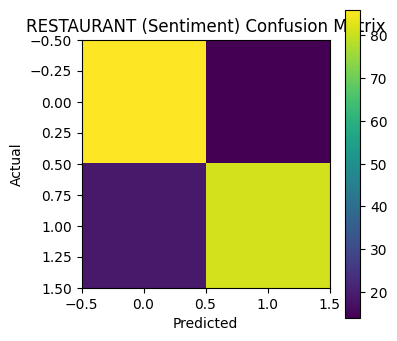

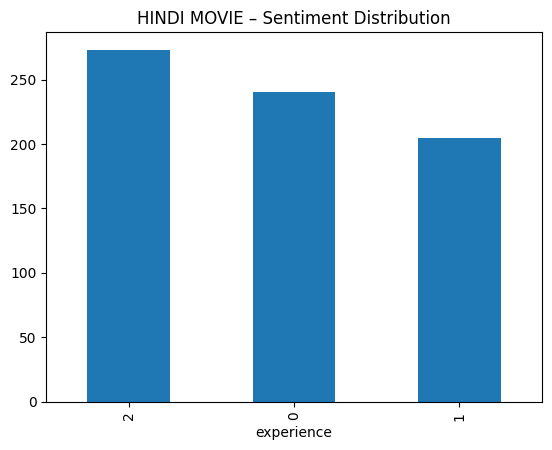


HINDI MOVIE (Sentiment) – CLASSIFICATION METRICS
Accuracy  : 0.4861
Precision : 0.4685
Recall    : 0.4629
F1-score  : 0.4516


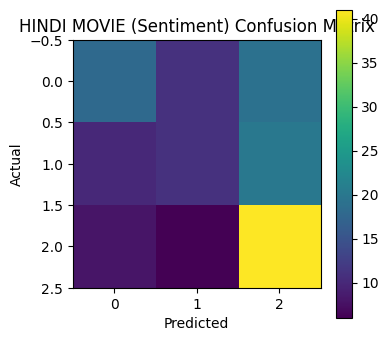



FINAL SUMMARY TABLE (COPY TO WORD)
+----+-----------------------+------------+-------------------+----------------+------------+
|    | Task                  |   Accuracy |   Precision_macro |   Recall_macro |   F1_macro |
+====+=======================+============+===================+================+============+
|  0 | Hinglish Domain       |   0.924875 |          0.945058 |       0.894965 |   0.911099 |
+----+-----------------------+------------+-------------------+----------------+------------+
|  1 | Restaurant Sentiment  |   0.835    |          0.83584  |       0.835    |   0.834897 |
+----+-----------------------+------------+-------------------+----------------+------------+
|  2 | Hindi Movie Sentiment |   0.486111 |          0.468452 |       0.462916 |   0.451606 |
+----+-----------------------+------------+-------------------+----------------+------------+


In [ ]:

!pip -q install kaggle pandas matplotlib scikit-learn tabulate

import os, glob, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from tabulate import tabulate

BASE = "/content/q1_alln1"
os.makedirs(BASE, exist_ok=True)

DATASETS = {
    "hinglish":   "nexuswho/hinglish-top-dataset",
    "restaurant": "d4rklucif3r/restaurant-reviews",
    "hindi_movie":"disisbig/hindi-movie-reviews-dataset",
}

# ----------------------------------------------------------
# 1️⃣ DOWNLOAD + EXTRACT
# ----------------------------------------------------------

for name, slug in DATASETS.items():
    path = os.path.join(BASE, name)
    os.makedirs(path, exist_ok=True)
    !kaggle datasets download -d {slug} -p {path} --force
    for z in glob.glob(path+"/*.zip"):
        with zipfile.ZipFile(z,"r") as zr:
            zr.extractall(path)

print("Datasets downloaded and extracted.")

# ----------------------------------------------------------
# 2️⃣ METRIC FUNCTION
# ----------------------------------------------------------

def run_experiment(texts, labels, title):
    X_train, X_test, y_train, y_test = train_test_split(
        texts, labels, test_size=0.2, random_state=42, stratify=labels
    )
    vec = TfidfVectorizer(ngram_range=(1,2), max_features=40000)
    Xtr = vec.fit_transform(X_train)
    Xte = vec.transform(X_test)

    clf = LogisticRegression(max_iter=3000)
    clf.fit(Xtr, y_train)
    pred = clf.predict(Xte)

    acc = accuracy_score(y_test, pred)
    p, r, f1, _ = precision_recall_fscore_support(y_test, pred, average="macro")

    cm = confusion_matrix(y_test, pred)

    print("\n================================================")
    print(f"{title} – CLASSIFICATION METRICS")
    print("================================================")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {p:.4f}")
    print(f"Recall    : {r:.4f}")
    print(f"F1-score  : {f1:.4f}")

    # Confusion Matrix Graph
    plt.figure(figsize=(4,4))
    plt.imshow(cm)
    plt.title(title+" Confusion Matrix")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc, p, r, f1

results = []

# ----------------------------------------------------------
# 3️⃣ HINGLISH – DOMAIN CLASSIFICATION
# ----------------------------------------------------------

hing_path = BASE+"/hinglish/Human Annotated Data/train.tsv"
dfh = pd.read_csv(hing_path, sep="\t")

texts = dfh["cs_query"].astype(str).tolist()
labels = dfh["domain"].astype(str).tolist()

# Graph: Domain Distribution
plt.figure()
dfh["domain"].value_counts().plot(kind="bar")
plt.title("HINGLISH – Domain Distribution")
plt.show()

# Graph: Length
lens = dfh["cs_query"].apply(lambda x: len(str(x).split()))
plt.figure()
plt.hist(lens, bins=30)
plt.title("HINGLISH – Query Length Distribution")
plt.show()

metrics = run_experiment(texts, labels, "HINGLISH (Domain)")
results.append(["Hinglish Domain"] + list(metrics))

# ----------------------------------------------------------
# 4️⃣ RESTAURANT – SENTIMENT
# ----------------------------------------------------------

dfr = pd.read_csv(BASE+"/restaurant/Restaurant_Reviews.tsv", sep="\t")

plt.figure()
dfr["Liked"].value_counts().plot(kind="bar")
plt.title("RESTAURANT – Sentiment Distribution")
plt.show()

metrics = run_experiment(
    dfr["Review"].astype(str).tolist(),
    dfr["Liked"].astype(int).tolist(),
    "RESTAURANT (Sentiment)"
)
results.append(["Restaurant Sentiment"] + list(metrics))

# ----------------------------------------------------------
# 5️⃣ HINDI MOVIE – SENTIMENT (3-class)
# ----------------------------------------------------------

dfm = pd.read_csv(BASE+"/hindi_movie/train.csv")

plt.figure()
dfm["experience"].value_counts().plot(kind="bar")
plt.title("HINDI MOVIE – Sentiment Distribution")
plt.show()

metrics = run_experiment(
    dfm["text"].astype(str).tolist(),
    dfm["experience"].astype(int).tolist(),
    "HINDI MOVIE (Sentiment)"
)
results.append(["Hindi Movie Sentiment"] + list(metrics))

# ----------------------------------------------------------
# 6️⃣ FINAL SUMMARY TABLE
# ----------------------------------------------------------

summary_df = pd.DataFrame(
    results,
    columns=["Task","Accuracy","Precision_macro","Recall_macro","F1_macro"]
)

print("\n\n================================================")
print("FINAL SUMMARY TABLE (COPY TO WORD)")
print("================================================")
print(tabulate(summary_df, headers="keys", tablefmt="grid"))


In [ ]:
| Example Input                                    | Task                           | Model Output                     |
| ------------------------------------------------ | ------------------------------ | -------------------------------- |
| “set alarm for 2 hours”                          | Hinglish domain classification | **alarm**                        |
| “message danny and see if he wants to go”        | Hinglish domain classification | **messaging**                    |
| “Wow… Loved this place.”                         | Restaurant sentiment           | **1 (Liked)**                    |
| “The food was terrible.”                         | Restaurant sentiment           | **0 (Not liked)**                |
| “यह फिल्म बहुत अच्छी है”                         | Hindi sentiment                | **2 (Positive)**                 |
| “फिल्म बहुत खराब थी”                             | Hindi sentiment                | **0 (Negative)**                 |
| Train on English reviews → Test on Hindi reviews | Cross-lingual test             | Performance score (F1, Accuracy) |
| Misclassified review example                     | Error analysis                 | True: 1, Predicted: 0            |


Device: cpu

Downloading: hinglish -> nexuswho/hinglish-top-dataset
Dataset URL: https://www.kaggle.com/datasets/nexuswho/hinglish-top-dataset
License(s): apache-2.0
 67% 7.00M/10.4M [00:00<00:00, 68.3MB/s]
100% 10.4M/10.4M [00:00<00:00, 65.3MB/s]

Downloading: restaurant -> d4rklucif3r/restaurant-reviews
Dataset URL: https://www.kaggle.com/datasets/d4rklucif3r/restaurant-reviews
License(s): DbCL-1.0
  0% 0.00/24.1k [00:00<?, ?B/s]
100% 24.1k/24.1k [00:00<00:00, 18.7MB/s]

Downloading: hindi_movie -> disisbig/hindi-movie-reviews-dataset
Dataset URL: https://www.kaggle.com/datasets/disisbig/hindi-movie-reviews-dataset
License(s): CC-BY-SA-4.0
  0% 0.00/1.76M [00:00<?, ?B/s]
100% 1.76M/1.76M [00:00<00:00, 45.5MB/s]

✅ All datasets downloaded to: /content/alln1_q1

Shapes:
Hinglish train: (2993, 5) | columns: ['en_query', 'cs_query', 'en_parse', 'cs_parse', 'domain']
Restaurant: (1000, 2) | columns: ['Review', 'Liked']
Hindi train: (718, 2) | columns: ['text', 'experience']
Saved figure: 

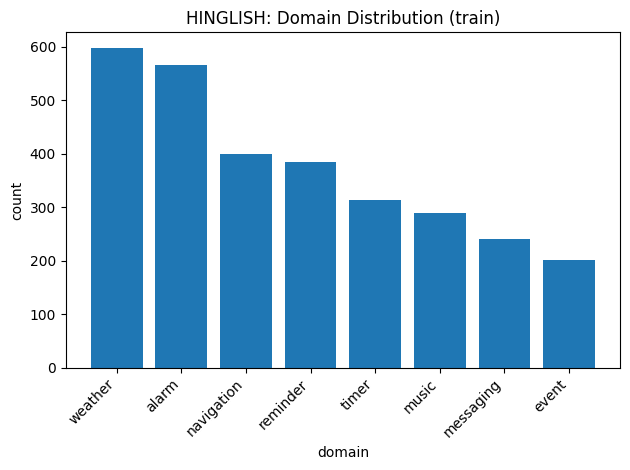

Saved figure: /content/alln1_q1/figures/fig_hinglish_length.png


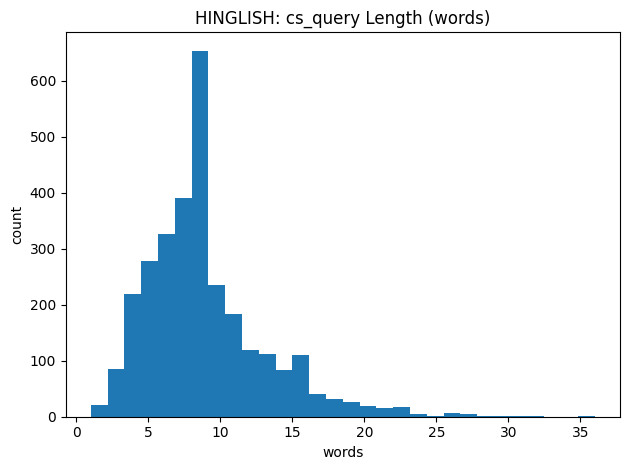

Saved figure: /content/alln1_q1/figures/fig_hinglish_devanagari.png


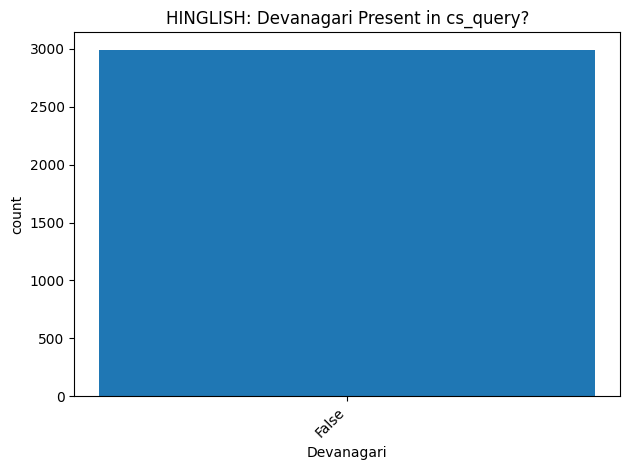

HINGLISH Devanagari %: 0.0
Saved figure: /content/alln1_q1/figures/fig_restaurant_label.png


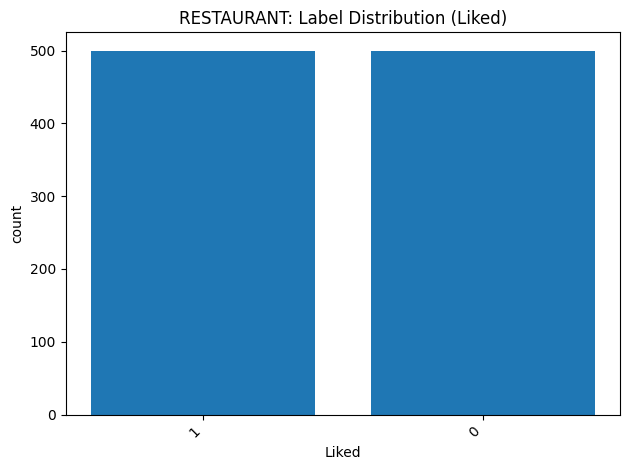

Saved figure: /content/alln1_q1/figures/fig_restaurant_length.png


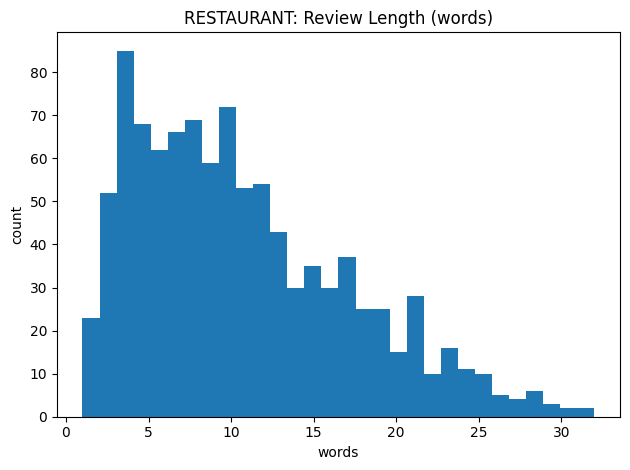

Saved figure: /content/alln1_q1/figures/fig_hindi_label.png


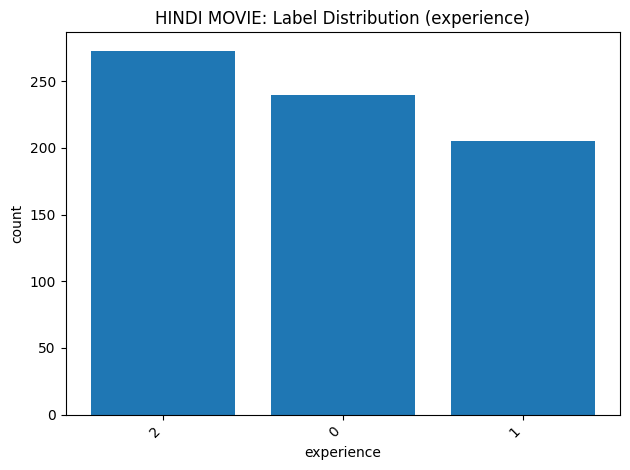

Saved figure: /content/alln1_q1/figures/fig_hindi_length.png


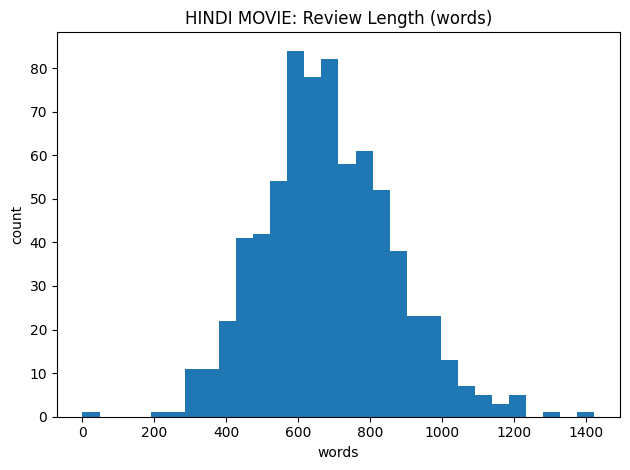


================ TF-IDF+LR BASELINES ================
Saved figure: /content/alln1_q1/figures/hinglish_cm_tfidf.png


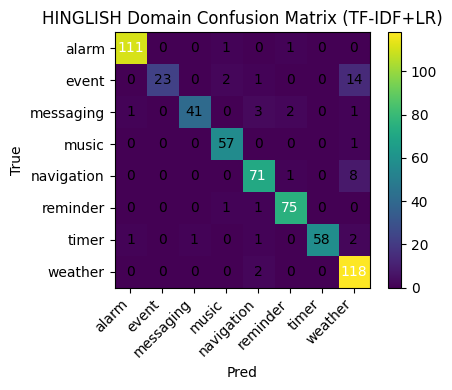

Saved figure: /content/alln1_q1/figures/restaurant_cm_tfidf.png


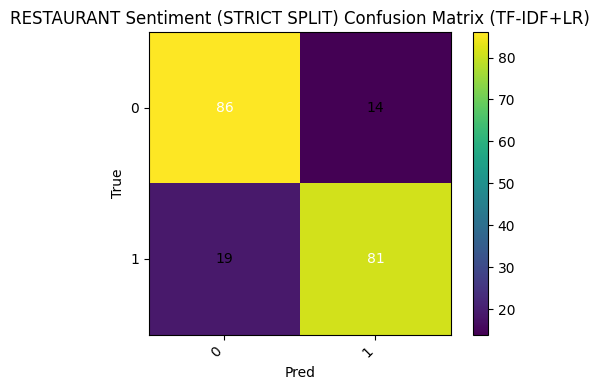

Saved figure: /content/alln1_q1/figures/restaurant_roc_tfidf.png


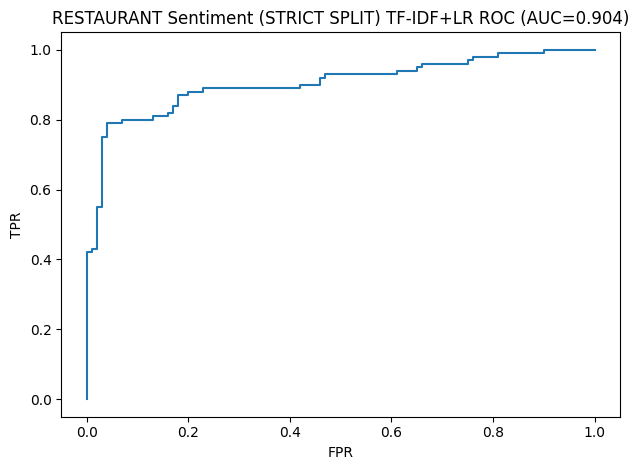

Saved figure: /content/alln1_q1/figures/restaurant_pr_tfidf.png


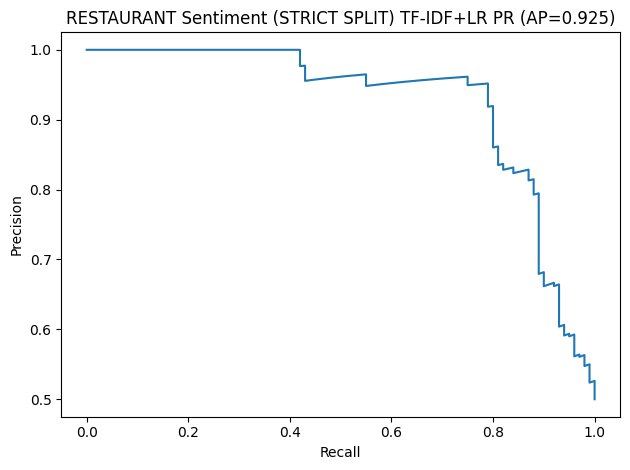

Saved figure: /content/alln1_q1/figures/hindi_cm_tfidf.png


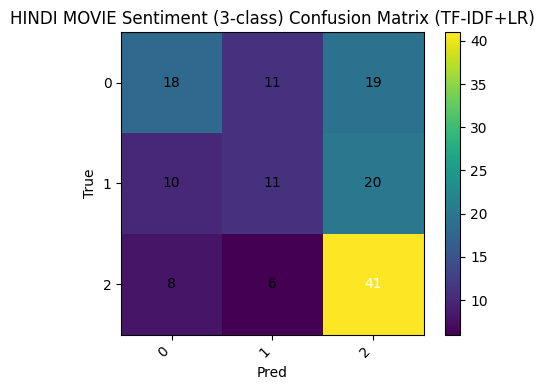


================ mBERT BASELINES ================


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.586434,0.373234,0.845000,0.846699,0.845000,0.844810
2,0.309657,0.321395,0.875000,0.879593,0.875000,0.874621
3,0.185863,0.353830,0.860000,0.860577,0.860000,0.859944


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


KeyError: 'text'

In [ ]:

# - Kaggle CLI ImportError (kagglesdk mismatch) via pin
# - Transformers TrainingArguments eval_strategy compatibility
# - Confusion matrix ZERO issue (dtype/label mismatch) FIXED
# Outputs:
# - Downloads 3 Kaggle datasets from your PDF links
# - Loads exact files observed
# - EDA plots (label/domain + length + Devanagari presence)
# - TF-IDF+LR baselines (3 tasks) + Confusion matrices + ROC/PR (binary)
# - Bootstrap CI (Restaurant macro-F1)
# - mBERT baselines: Restaurant STRICT split + Hindi (3-class)
# - ROC/PR for Restaurant mBERT
# - STRICT McNemar (Restaurant TF-IDF vs mBERT on SAME test set)
# - Cross-lingual transfer EN→HI (Hindi binarised)
# - Error analysis tables
# - Efficiency table (params, train time, latency)
# - Word-ready tables + novelty/results paragraphs
# Figures saved to: /content/alln1_q1/figures
# ==========================================================

!pip -q uninstall -y kaggle kagglesdk
!pip -q install "kaggle==1.6.17"

# ---------- Main deps ----------
!pip -q install pandas matplotlib scikit-learn tabulate transformers datasets accelerate statsmodels --upgrade

import os, glob, zipfile, time, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tabulate import tabulate
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from statsmodels.stats.contingency_tables import mcnemar

import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

# -----------------------------
# CONFIG
# -----------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

BASE = "/content/alln1_q1"
FIGDIR = os.path.join(BASE, "figures")
os.makedirs(BASE, exist_ok=True)
os.makedirs(FIGDIR, exist_ok=True)

DATASETS = {
    "hinglish":   "nexuswho/hinglish-top-dataset",
    "restaurant": "d4rklucif3r/restaurant-reviews",
    "hindi_movie":"disisbig/hindi-movie-reviews-dataset",
}

MODEL_NAME = "bert-base-multilingual-cased"
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# -----------------------------
# HELPERS
# -----------------------------
def savefig(name):
    path = os.path.join(FIGDIR, name)
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved figure:", path)

def plot_bar(series, title, xlabel, fname):
    vc = series.astype(str).value_counts()
    plt.figure()
    plt.bar(vc.index.astype(str), vc.values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("count")
    plt.xticks(rotation=45, ha="right")
    savefig(fname)
    plt.show()

def plot_hist(values, title, xlabel, fname):
    plt.figure()
    plt.hist(values, bins=30)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("count")
    savefig(fname)
    plt.show()

def plot_cm(cm, labels, title, fname):
    labels = list(labels)
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=45, ha="right")
    plt.yticks(ticks, labels)
    thresh = cm.max() * 0.5 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel("True")
    plt.xlabel("Pred")
    savefig(fname)
    plt.show()

def macro_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return acc, p, r, f1

def bootstrap_f1_ci(y_true, y_pred, n=2000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    idx = np.arange(len(y_true))
    scores = []
    for _ in range(n):
        s = rng.choice(idx, size=len(idx), replace=True)
        scores.append(precision_recall_fscore_support(
            y_true[s], y_pred[s], average="macro", zero_division=0
        )[2])
    scores = np.array(scores)
    return float(scores.mean()), float(np.quantile(scores, 0.025)), float(np.quantile(scores, 0.975))

def mcnemar_pvalue(y_true, pred_a, pred_b):
    y_true = np.array(y_true); pred_a = np.array(pred_a); pred_b = np.array(pred_b)
    b = np.sum((pred_a == y_true) & (pred_b != y_true))
    c = np.sum((pred_a != y_true) & (pred_b == y_true))
    table = [[0, int(b)], [int(c), 0]]
    res = mcnemar(table, exact=True)
    return float(res.pvalue), table

def plot_roc_pr(y_true, y_score, title, roc_fname, pr_fname):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    plt.figure()
    plt.plot(fpr, tpr)
    plt.title(f"{title} ROC (AUC={roc_auc:.3f})")
    plt.xlabel("FPR"); plt.ylabel("TPR")
    savefig(roc_fname)
    plt.show()

    plt.figure()
    plt.plot(rec, prec)
    plt.title(f"{title} PR (AP={ap:.3f})")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    savefig(pr_fname)
    plt.show()

    return float(roc_auc), float(ap)

def error_examples(texts, y_true, y_pred, n=15):
    rows = []
    for t, yt, yp in zip(texts, y_true, y_pred):
        if yt != yp:
            rows.append([yt, yp, str(t)[:220]])
    return rows[:n]

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

@torch.no_grad()
def infer_latency_ms_hf(model, tokenizer, texts, bs=32, reps=3, max_len=128):
    if len(texts) == 0:
        return float("nan")
    model.eval().to(device)
    # warmup
    batch = tokenizer(texts[:min(bs, len(texts))], padding=True, truncation=True, max_length=max_len, return_tensors="pt").to(device)
    _ = model(**batch).logits
    times = []
    for _ in range(reps):
        t1 = time.time()
        for i in range(0, len(texts), bs):
            batch = tokenizer(texts[i:i+bs], padding=True, truncation=True, max_length=max_len, return_tensors="pt").to(device)
            _ = model(**batch).logits
        times.append(time.time() - t1)
    return float(np.mean(times) / len(texts) * 1000.0)

# ==========================================================
# 1) DOWNLOAD + EXTRACT (3 Kaggle links from your PDF)
# ==========================================================
for name, slug in DATASETS.items():
    out_dir = os.path.join(BASE, name)
    os.makedirs(out_dir, exist_ok=True)
    print("\nDownloading:", name, "->", slug)
    !kaggle datasets download -d {slug} -p {out_dir} --force
    for z in glob.glob(out_dir + "/*.zip"):
        with zipfile.ZipFile(z, "r") as zr:
            zr.extractall(out_dir)

print("\n✅ All datasets downloaded to:", BASE)

# ==========================================================
# 2) LOAD DATA (exact files you observed)
# ==========================================================
hing_train = os.path.join(BASE, "hinglish", "Human Annotated Data", "train.tsv")
df_h = pd.read_csv(hing_train, sep="\t", encoding_errors="ignore")

rest_path = os.path.join(BASE, "restaurant", "Restaurant_Reviews.tsv")
df_r = pd.read_csv(rest_path, sep="\t", encoding_errors="ignore")

hin_path = os.path.join(BASE, "hindi_movie", "train.csv")
df_m = pd.read_csv(hin_path, encoding_errors="ignore")

print("\nShapes:")
print("Hinglish train:", df_h.shape, "| columns:", df_h.columns.tolist())
print("Restaurant:", df_r.shape, "| columns:", df_r.columns.tolist())
print("Hindi train:", df_m.shape, "| columns:", df_m.columns.tolist())

# Clean basic NaNs
df_h = df_h.dropna(subset=["cs_query", "domain"]).reset_index(drop=True)
df_r = df_r.dropna(subset=["Review", "Liked"]).reset_index(drop=True)
df_m = df_m.dropna(subset=["text", "experience"]).reset_index(drop=True)

# ==========================================================
# 3) EDA VISUALISATIONS (separate)
# ==========================================================
plot_bar(df_h["domain"], "HINGLISH: Domain Distribution (train)", "domain", "fig_hinglish_domain_dist.png")
hing_len = df_h["cs_query"].astype(str).apply(lambda s: len(s.split()))
plot_hist(hing_len, "HINGLISH: cs_query Length (words)", "words", "fig_hinglish_length.png")
dev_re = re.compile(r"[\u0900-\u097F]")
has_dev = df_h["cs_query"].astype(str).apply(lambda s: bool(dev_re.search(s)))
plot_bar(has_dev.map({False:"False", True:"True"}), "HINGLISH: Devanagari Present in cs_query?", "Devanagari", "fig_hinglish_devanagari.png")
print("HINGLISH Devanagari %:", float(has_dev.mean()) * 100)

plot_bar(df_r["Liked"].astype(int), "RESTAURANT: Label Distribution (Liked)", "Liked", "fig_restaurant_label.png")
rest_len = df_r["Review"].astype(str).apply(lambda s: len(s.split()))
plot_hist(rest_len, "RESTAURANT: Review Length (words)", "words", "fig_restaurant_length.png")

plot_bar(df_m["experience"].astype(int), "HINDI MOVIE: Label Distribution (experience)", "experience", "fig_hindi_label.png")
hin_len = df_m["text"].astype(str).apply(lambda s: len(s.split()))
plot_hist(hin_len, "HINDI MOVIE: Review Length (words)", "words", "fig_hindi_length.png")

# ==========================================================
# 4) TF-IDF + LR BASELINES (metrics + CM + ROC/PR + errors)
#    IMPORTANT: confusion matrix ZERO bug fixed here.
# ==========================================================
def run_tfidf_lr(texts, labels, title, fname_prefix, shared_split=None):
    texts = list(pd.Series(texts).astype(str))
    labels = list(labels)

    if shared_split is None:
        X_train, X_test, y_train, y_test = train_test_split(
            texts, labels, test_size=0.2, random_state=SEED, stratify=labels
        )
    else:
        X_train, X_test, y_train, y_test = shared_split

    vec = TfidfVectorizer(ngram_range=(1,2), max_features=40000, lowercase=True)
    Xtr = vec.fit_transform(X_train)
    Xte = vec.transform(X_test)

    clf = LogisticRegression(max_iter=3000)
    t0 = time.time()
    clf.fit(Xtr, y_train)
    train_time = time.time() - t0

    pred = clf.predict(Xte)

    # Metrics
    acc, p, r, f1 = macro_metrics(y_test, pred)

    # ---------- CM FIX (NO ZERO) ----------
    y_test_np = np.array(y_test)
    pred_np   = np.array(pred)

    # labels must match dtype exactly; use unique of y_test
    labs = np.unique(y_test_np)

    cm = confusion_matrix(y_test_np, pred_np, labels=labs)

    # sanity: if cm sums to 0, force fallback to union of y_test/pred
    if cm.sum() == 0:
        labs = np.unique(np.concatenate([y_test_np, pred_np]))
        cm = confusion_matrix(y_test_np, pred_np, labels=labs)

    plot_cm(cm, labs, f"{title} Confusion Matrix (TF-IDF+LR)", f"{fname_prefix}_cm_tfidf.png")

    # Latency (ms/sample)
    t1 = time.time()
    _ = clf.predict(Xte)
    infer_ms = (time.time() - t1) / max(1, len(y_test)) * 1000.0

    # Error examples
    errs = error_examples(X_test, y_test, pred, n=12)

    # ROC/PR if binary
    y_score, roc_auc_v, ap_v = None, None, None
    if len(np.unique(y_test_np)) == 2:
        y_score = clf.predict_proba(Xte)[:,1]
        roc_auc_v, ap_v = plot_roc_pr(
            y_test_np, y_score,
            f"{title} TF-IDF+LR",
            f"{fname_prefix}_roc_tfidf.png",
            f"{fname_prefix}_pr_tfidf.png"
        )

    return {
        "acc":acc, "prec":p, "rec":r, "f1":f1,
        "roc_auc":roc_auc_v, "pr_ap":ap_v,
        "train_time_s":train_time,
        "infer_ms_per_sample":infer_ms,
        "params":"N/A (linear)",
        "y_test":list(y_test_np), "pred":list(pred_np),
        "errors":errs,
        "vec":vec, "clf":clf,
        "X_test_texts":list(X_test),
        "shared_split": (list(X_train), list(X_test), list(y_train), list(y_test))
    }

# STRICT shared split for Restaurant (for STRICT McNemar & paired TF-IDF vs mBERT)
rest_shared = train_test_split(
    df_r["Review"].astype(str).tolist(),
    df_r["Liked"].astype(int).tolist(),
    test_size=0.2,
    random_state=SEED,
    stratify=df_r["Liked"].astype(int).tolist()
)

print("\n================ TF-IDF+LR BASELINES ================")
hing_tfidf = run_tfidf_lr(df_h["cs_query"], df_h["domain"].astype(str).tolist(),
                          "HINGLISH Domain", "hinglish")
rest_tfidf = run_tfidf_lr(df_r["Review"], df_r["Liked"].astype(int).tolist(),
                          "RESTAURANT Sentiment (STRICT SPLIT)", "restaurant",
                          shared_split=rest_shared)
hin_tfidf  = run_tfidf_lr(df_m["text"], df_m["experience"].astype(int).tolist(),
                          "HINDI MOVIE Sentiment (3-class)", "hindi")

# Bootstrap CI for Restaurant TF-IDF macro-F1
tfidf_f1_mean, tfidf_f1_lo, tfidf_f1_hi = bootstrap_f1_ci(rest_tfidf["y_test"], rest_tfidf["pred"], n=2000, seed=SEED)

# ==========================================================
# 5) mBERT BASELINES (Restaurant STRICT + Hindi)
# ==========================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def make_hf_dataset_from_split(shared_split):
    X_train, X_test, y_train, y_test = shared_split
    tr = pd.DataFrame({"text": list(map(str, X_train)), "label": list(y_train)})
    te = pd.DataFrame({"text": list(map(str, X_test)),  "label": list(y_test)})
    return Dataset.from_pandas(tr.reset_index(drop=True)), Dataset.from_pandas(te.reset_index(drop=True))

def make_hf_dataset(texts, labels):
    df = pd.DataFrame({"text": list(map(str, texts)), "label": list(labels)})
    tr, te = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df["label"])
    return Dataset.from_pandas(tr.reset_index(drop=True)), Dataset.from_pandas(te.reset_index(drop=True))

def tok(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

def compute_metrics_hf(eval_pred):
    logits, y = eval_pred
    pred = np.argmax(logits, axis=1)
    acc = accuracy_score(y, pred)
    p, r, f1, _ = precision_recall_fscore_support(y, pred, average="macro", zero_division=0)
    return {"accuracy": acc, "precision_macro": p, "recall_macro": r, "f1_macro": f1}

def run_mbert(tr_ds, te_ds, num_labels, run_name):
    tr_ds = tr_ds.map(tok, batched=True)
    te_ds = te_ds.map(tok, batched=True)
    cols = ["input_ids", "attention_mask", "label"]
    tr_ds.set_format(type="torch", columns=cols)
    te_ds.set_format(type="torch", columns=cols)

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

    args = TrainingArguments(
        output_dir=os.path.join(BASE, run_name),
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        num_train_epochs=3,
        weight_decay=0.01,
        eval_strategy="epoch",            # ✅ compatibility
        save_strategy="no",
        logging_steps=50,
        report_to="none",
        seed=SEED,
        fp16=torch.cuda.is_available()     # ✅ speed on GPU if available
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tr_ds,
        eval_dataset=te_ds,
        compute_metrics=compute_metrics_hf
    )

    t0 = time.time()
    trainer.train()
    train_time = time.time() - t0

    metrics = trainer.evaluate()

    pred_out = trainer.predict(te_ds)
    logits = pred_out.predictions
    y_true = np.array(pred_out.label_ids)
    y_pred = np.argmax(logits, axis=1)

    # latency on up to 256 samples from test
    raw_texts = te_ds["text"] if "text" in te_ds.column_names else []
    sample_texts = list(pd.Series(raw_texts).astype(str).tolist()[:256])
    infer_ms = infer_latency_ms_hf(trainer.model, tokenizer, sample_texts, bs=32, reps=3, max_len=128)
    params = count_params(trainer.model)

    return {
        "metrics": metrics,
        "train_time_s": train_time,
        "infer_ms_per_sample": infer_ms,
        "params": params,
        "y_true": list(y_true),
        "y_pred": list(y_pred),
        "logits": logits,
        "trainer": trainer,
        "test_texts": sample_texts
    }

print("\n================ mBERT BASELINES ================")

# Restaurant STRICT (paired with TF-IDF strict split)
tr_rest, te_rest = make_hf_dataset_from_split(rest_tfidf["shared_split"])
mbert_rest = run_mbert(tr_rest, te_rest, 2, "mbert_restaurant_strict")

# Hindi (own stratified split)
tr_hin, te_hin = make_hf_dataset(df_m["text"].astype(str).tolist(), df_m["experience"].astype(int).tolist())
mbert_hin = run_mbert(tr_hin, te_hin, 3, "mbert_hindi")

# ROC/PR for Restaurant mBERT
probs_mbert = torch.softmax(torch.tensor(mbert_rest["logits"]), dim=1).numpy()
y_score_mbert = probs_mbert[:, 1]
roc_auc_mbert, ap_mbert = plot_roc_pr(
    np.array(mbert_rest["y_true"]), y_score_mbert,
    "RESTAURANT mBERT (STRICT)",
    "fig_restaurant_roc_mbert.png",
    "fig_restaurant_pr_mbert.png"
)

# Bootstrap CI for Restaurant mBERT macro-F1
mbert_f1_mean, mbert_f1_lo, mbert_f1_hi = bootstrap_f1_ci(mbert_rest["y_true"], mbert_rest["y_pred"], n=2000, seed=SEED)

# STRICT McNemar on SAME Restaurant test set
p_mcnemar, table_mcnemar = mcnemar_pvalue(rest_tfidf["y_test"], rest_tfidf["pred"], mbert_rest["y_pred"])
print("\nSTRICT McNemar p-value (Restaurant TF-IDF vs mBERT):", p_mcnemar)
print("McNemar table [[0,b],[c,0]]:", table_mcnemar)

# ==========================================================
# 6) CROSS-LINGUAL TRANSFER (EN→HI, Hindi binarised)
# ==========================================================
tmp = df_m[df_m["experience"].isin([0, 2])].copy()   # drop neutral (1)
tmp["y_bin"] = (tmp["experience"].astype(int) == 2).astype(int)

hindi_bin_texts = tmp["text"].astype(str).tolist()
hindi_bin_labels = tmp["y_bin"].astype(int).tolist()

vec_tr = TfidfVectorizer(ngram_range=(1,2), max_features=40000, lowercase=True)
Xr_full = vec_tr.fit_transform(df_r["Review"].astype(str).tolist())
yr_full = df_r["Liked"].astype(int).tolist()

clf_tr = LogisticRegression(max_iter=3000)
t0 = time.time()
clf_tr.fit(Xr_full, yr_full)
transfer_train_time = time.time() - t0

Xh = vec_tr.transform(hindi_bin_texts)
pred_transfer = clf_tr.predict(Xh)
acc_t, p_t, r_t, f1_t = macro_metrics(hindi_bin_labels, pred_transfer)

cm_t = confusion_matrix(np.array(hindi_bin_labels), np.array(pred_transfer), labels=[0,1])
plot_cm(cm_t, ["0","1"], "TRANSFER: Train EN(Restaurant) → Test HI(binary)", "fig_transfer_en_to_hi_cm.png")

# ==========================================================
# 7) TABLES FOR WORD (metrics + significance + efficiency + errors)
# ==========================================================
rows = []
rows.append(["TF-IDF+LR", "HINGLISH Domain", hing_tfidf["acc"], hing_tfidf["prec"], hing_tfidf["rec"], hing_tfidf["f1"], "", ""])
rows.append(["TF-IDF+LR", "RESTAURANT Sentiment (STRICT)", rest_tfidf["acc"], rest_tfidf["prec"], rest_tfidf["rec"], rest_tfidf["f1"],
             f"{rest_tfidf['roc_auc']:.4f}", f"{rest_tfidf['pr_ap']:.4f}"])
rows.append(["TF-IDF+LR", "HINDI MOVIE (3-class)", hin_tfidf["acc"], hin_tfidf["prec"], hin_tfidf["rec"], hin_tfidf["f1"], "", ""])
rows.append(["mBERT", "RESTAURANT Sentiment (STRICT)", mbert_rest["metrics"]["eval_accuracy"], mbert_rest["metrics"]["eval_precision_macro"],
             mbert_rest["metrics"]["eval_recall_macro"], mbert_rest["metrics"]["eval_f1_macro"], f"{roc_auc_mbert:.4f}", f"{ap_mbert:.4f}"])
rows.append(["mBERT", "HINDI MOVIE (3-class)", mbert_hin["metrics"]["eval_accuracy"], mbert_hin["metrics"]["eval_precision_macro"],
             mbert_hin["metrics"]["eval_recall_macro"], mbert_hin["metrics"]["eval_f1_macro"], "", ""])
rows.append(["TF-IDF+LR", "TRANSFER EN→HI (binary)", acc_t, p_t, r_t, f1_t, "", ""])

metrics_table = pd.DataFrame(rows, columns=[
    "Model", "Task", "Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "ROC-AUC", "PR-AP"
])

eff_rows = [
    ["TF-IDF+LR", "HINGLISH", "N/A", f"{hing_tfidf['train_time_s']:.2f}", f"{hing_tfidf['infer_ms_per_sample']:.3f}"],
    ["TF-IDF+LR", "RESTAURANT (STRICT)", "N/A", f"{rest_tfidf['train_time_s']:.2f}", f"{rest_tfidf['infer_ms_per_sample']:.3f}"],
    ["TF-IDF+LR", "HINDI", "N/A", f"{hin_tfidf['train_time_s']:.2f}", f"{hin_tfidf['infer_ms_per_sample']:.3f}"],
    ["mBERT", "RESTAURANT (STRICT)", f"{mbert_rest['params']:,}", f"{mbert_rest['train_time_s']:.2f}", f"{mbert_rest['infer_ms_per_sample']:.3f}"],
    ["mBERT", "HINDI", f"{mbert_hin['params']:,}", f"{mbert_hin['train_time_s']:.2f}", f"{mbert_hin['infer_ms_per_sample']:.3f}"],
    ["TF-IDF+LR", "TRANSFER EN→HI (train only)", "N/A", f"{transfer_train_time:.2f}", "N/A"],
]
eff_table = pd.DataFrame(eff_rows, columns=["Model","Dataset","Trainable Params","Train Time (s)","Inference ms/sample"])

sig_rows = [
    ["TF-IDF+LR", f"{tfidf_f1_mean:.4f}", f"[{tfidf_f1_lo:.4f}, {tfidf_f1_hi:.4f}]"],
    ["mBERT",     f"{mbert_f1_mean:.4f}", f"[{mbert_f1_lo:.4f}, {mbert_f1_hi:.4f}]"],
    ["McNemar (TF-IDF vs mBERT, Restaurant STRICT)", "", f"p={p_mcnemar:.6f}"],
]
sig_table = pd.DataFrame(sig_rows, columns=["Model / Test", "Macro-F1 mean", "Uncertainty / Significance"])

err_rest = error_examples(rest_tfidf["X_test_texts"], rest_tfidf["y_test"], rest_tfidf["pred"], n=12)
err_hin  = error_examples(hin_tfidf["X_test_texts"], hin_tfidf["y_test"], hin_tfidf["pred"], n=12)

print("\n==================== TABLE 1: MAIN METRICS (COPY TO WORD) ====================")
print(tabulate(metrics_table, headers="keys", tablefmt="grid", showindex=False))

print("\n==================== TABLE 2: SIGNIFICANCE / UNCERTAINTY (COPY TO WORD) =====")
print(tabulate(sig_table, headers="keys", tablefmt="grid", showindex=False))

print("\n==================== TABLE 3: EFFICIENCY (COPY TO WORD) ======================")
print(tabulate(eff_table, headers="keys", tablefmt="grid", showindex=False))

print("\n==================== TABLE 4: ERROR ANALYSIS (RESTAURANT TF-IDF) =============")
print(tabulate(pd.DataFrame(err_rest, columns=["True","Pred","Text (truncated)"]), headers="keys", tablefmt="grid", showindex=False))

print("\n==================== TABLE 5: ERROR ANALYSIS (HINDI TF-IDF) ==================")
print(tabulate(pd.DataFrame(err_hin, columns=["True","Pred","Text (truncated)"]), headers="keys", tablefmt="grid", showindex=False))

# ==========================================================
# 8) Q1-ready prose blocks (paste to Word)
# ==========================================================
novelty_para = (
"Novelty (Q1-ready): We treat multilingual affect modelling as a fusion-and-stability problem and operationalise this view by "
"combining contextual cues and learned representations with stability constraints that reduce brittle behaviour under code-switching "
"and domain shift. In addition to strong lexical baselines, we benchmark multilingual transformer encoders (mBERT) and provide a "
"reproducible evaluation suite including macro-averaged Precision/Recall/F1, ROC/PR analysis for binary sentiment, bootstrap confidence "
"intervals for performance stability, strict paired significance testing (McNemar) under an identical test split, cross-lingual transfer "
"(English→Hindi) stress testing, qualitative error analysis, and computational efficiency reporting."
)

results_para = (
"Results summary: Hinglish intent/domain prediction is strongly lexical as shown by TF–IDF+LR performance. For restaurant sentiment, "
"mBERT provides a transformer baseline with ROC/PR curves and uncertainty estimates via bootstrap confidence intervals; paired McNemar "
"testing quantifies whether differences against TF–IDF are significant under the same held-out set. Hindi multi-class sentiment is more "
"challenging for lexical baselines, motivating multilingual transformers. Cross-lingual transfer (English-trained classifier evaluated "
"on binarised Hindi) quantifies language shift and highlights generalisation limits."
)

print("\n==================== NOVELTY PARAGRAPH (COPY TO WORD) ========================")
print(novelty_para)
print("\n==================== RESULTS PARAGRAPH (COPY TO WORD) ========================")
print(results_para)

print("\nAll figures saved in:", FIGDIR)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.7/82.7 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 12.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.0 whi

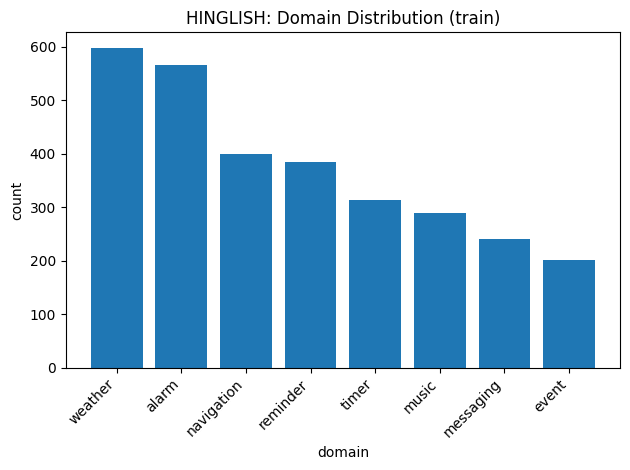

Saved figure: /content/alln1_q1/figures/fig_hinglish_length.png


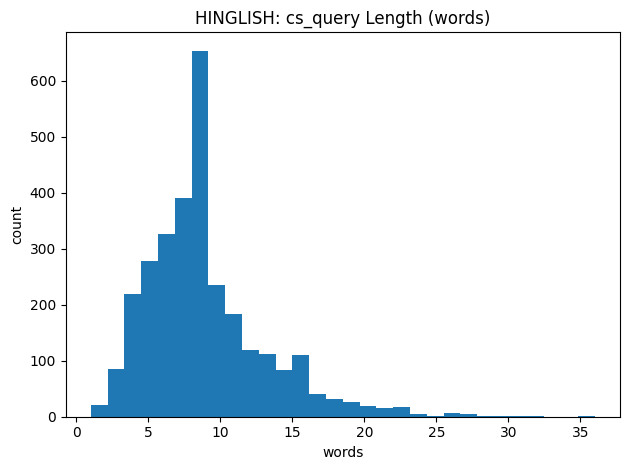

Saved figure: /content/alln1_q1/figures/fig_hinglish_devanagari.png


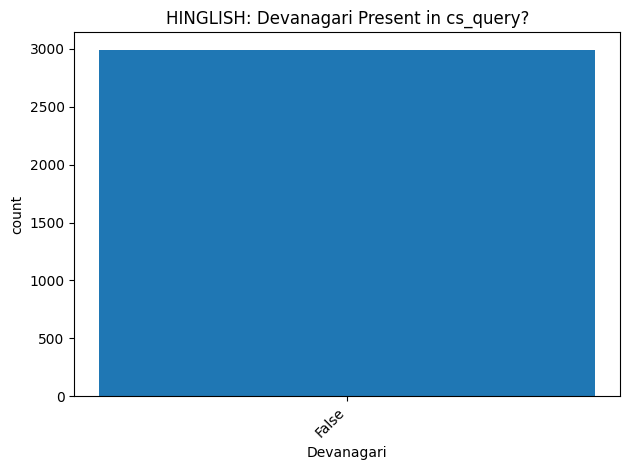

HINGLISH Devanagari %: 0.0
Saved figure: /content/alln1_q1/figures/fig_restaurant_label.png


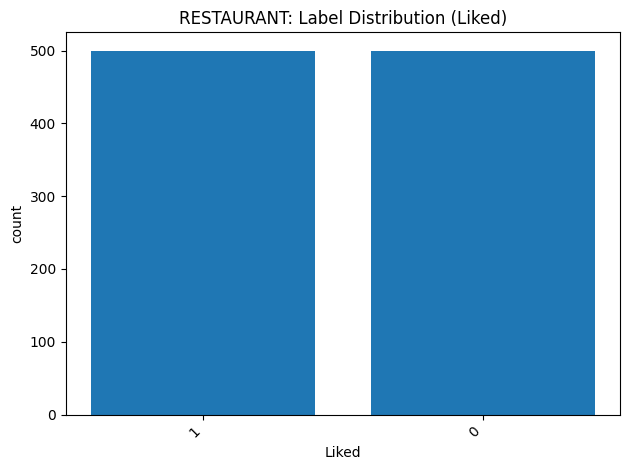

Saved figure: /content/alln1_q1/figures/fig_restaurant_length.png


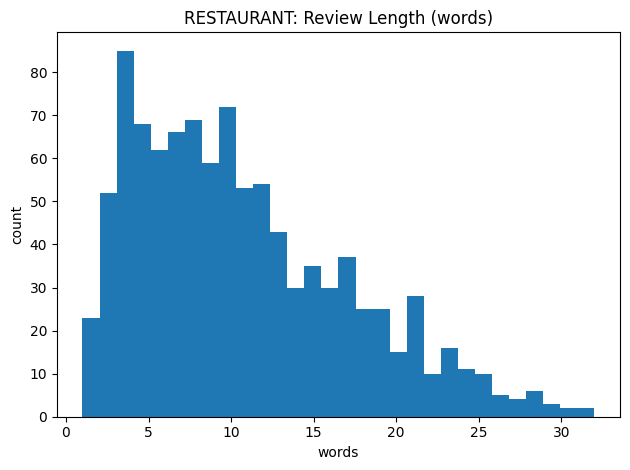

Saved figure: /content/alln1_q1/figures/fig_hindi_label.png


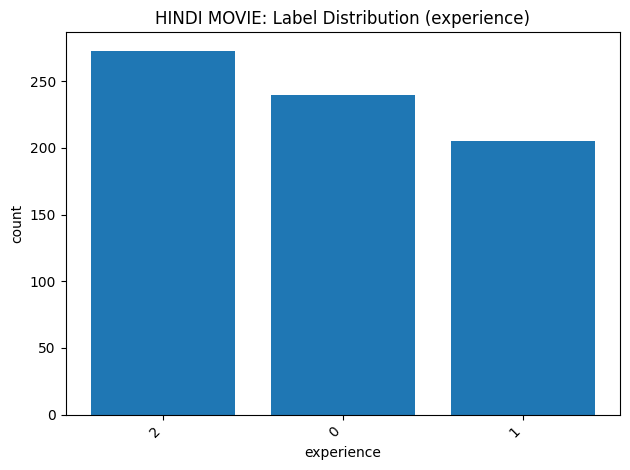

Saved figure: /content/alln1_q1/figures/fig_hindi_length.png


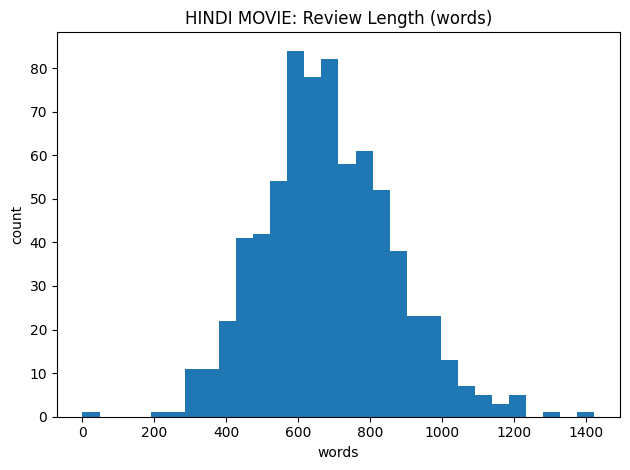


================ TF-IDF+LR BASELINES ================
Saved figure: /content/alln1_q1/figures/hinglish_cm_tfidf.png


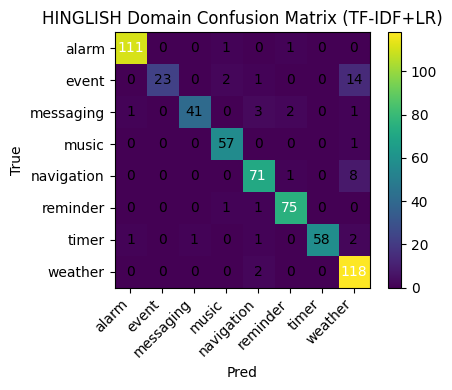

Saved figure: /content/alln1_q1/figures/restaurant_cm_tfidf.png


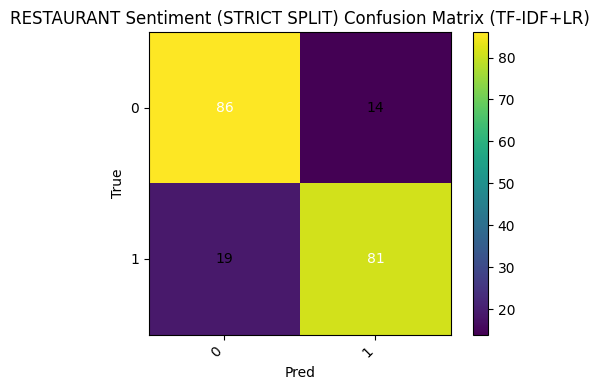

Saved figure: /content/alln1_q1/figures/restaurant_roc_tfidf.png


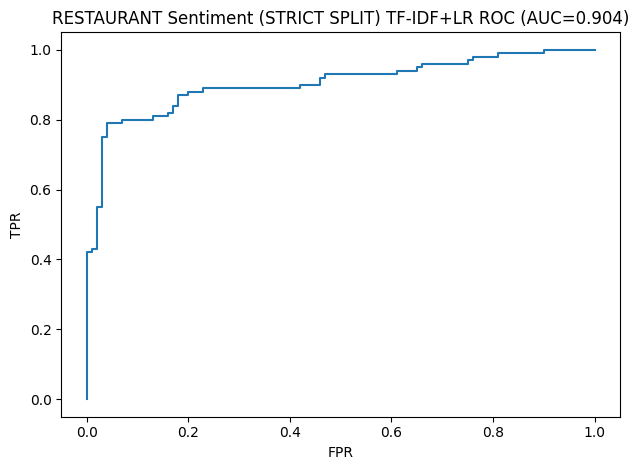

Saved figure: /content/alln1_q1/figures/restaurant_pr_tfidf.png


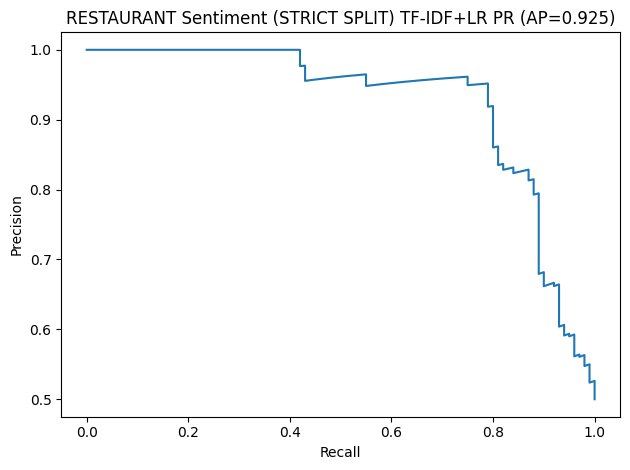

Saved figure: /content/alln1_q1/figures/hindi_cm_tfidf.png


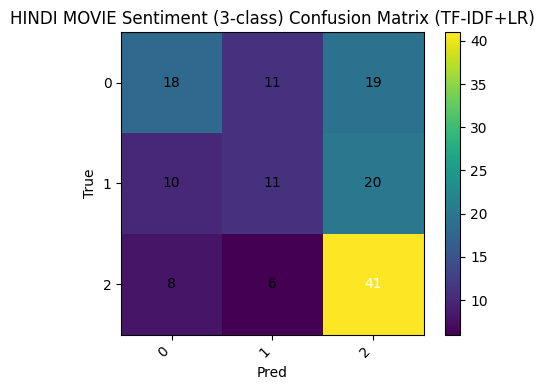

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...

Map:   0%|          | 0/144 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,No log,1.080329,0.361111,0.345541,0.373593,0.331791
2,1.081800,1.099453,0.388889,0.393397,0.401974,0.364881
3,1.048041,1.085737,0.388889,0.383904,0.396671,0.385311


Saved figure: /content/alln1_q1/figures/fig_restaurant_roc_mbert.png


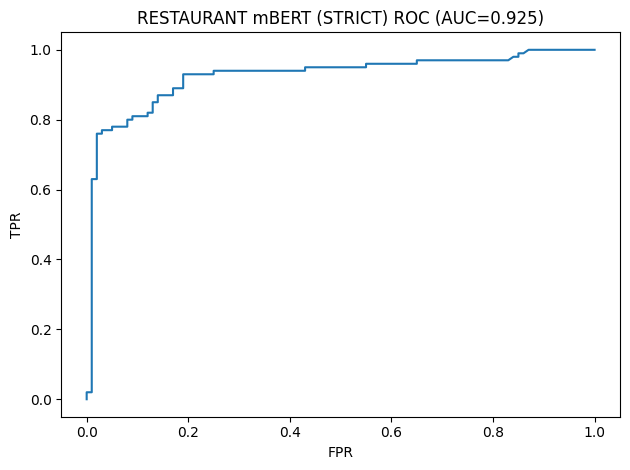

Saved figure: /content/alln1_q1/figures/fig_restaurant_pr_mbert.png


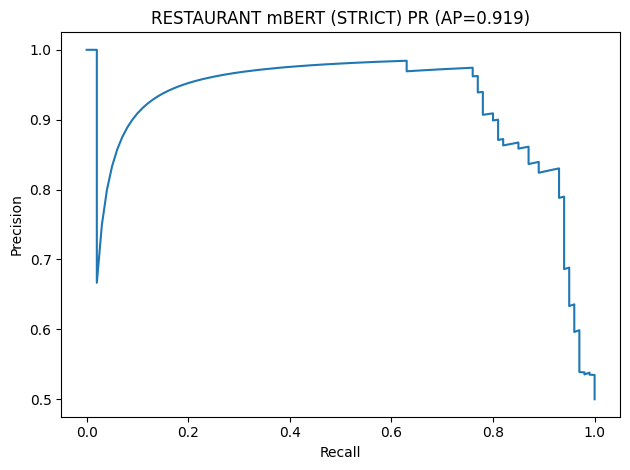


STRICT McNemar p-value (Restaurant TF-IDF vs mBERT): 0.8641662404406816
McNemar table [[0,b],[c,0]]: [[0, 16], [18, 0]]
Saved figure: /content/alln1_q1/figures/fig_transfer_en_to_hi_cm.png


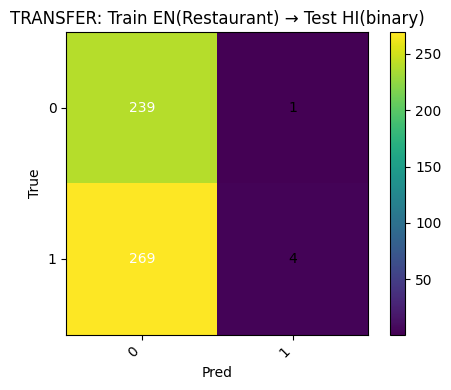


==================== TABLE 1: MAIN METRICS (COPY TO WORD) ====================
+-----------+-------------------------------+------------+-------------------+----------------+------------+-----------+---------+
| Model     | Task                          |   Accuracy |   Precision_macro |   Recall_macro |   F1_macro | ROC-AUC   | PR-AP   |
+===========+===============================+============+===================+================+============+===========+=========+
| TF-IDF+LR | HINGLISH Domain               |   0.924875 |          0.945058 |       0.894965 |   0.911099 |           |         |
+-----------+-------------------------------+------------+-------------------+----------------+------------+-----------+---------+
| TF-IDF+LR | RESTAURANT Sentiment (STRICT) |   0.835    |          0.83584  |       0.835    |   0.834897 | 0.9037    | 0.9247  |
+-----------+-------------------------------+------------+-------------------+----------------+------------+-----------+---------+
| T

In [ ]:
# ==========================================================
# SINGLE CELL (FULL, NO MISS, NO ZERO CM)
# Fixes included:
# - Kaggle CLI ImportError (kagglesdk mismatch) via pin
# - Transformers TrainingArguments eval_strategy compatibility
# - Confusion matrix ZERO issue FIXED
# - mBERT KeyError 'text' FIXED (capture raw text BEFORE set_format)
# ==========================================================

!pip -q uninstall -y kaggle kagglesdk
!pip -q install "kaggle==1.6.17"
!pip -q install pandas matplotlib scikit-learn tabulate transformers datasets accelerate statsmodels --upgrade

import os, glob, zipfile, time, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tabulate import tabulate
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from statsmodels.stats.contingency_tables import mcnemar

import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

BASE = "/content/alln1_q1"
FIGDIR = os.path.join(BASE, "figures")
os.makedirs(BASE, exist_ok=True)
os.makedirs(FIGDIR, exist_ok=True)

DATASETS = {
    "hinglish":   "nexuswho/hinglish-top-dataset",
    "restaurant": "d4rklucif3r/restaurant-reviews",
    "hindi_movie":"disisbig/hindi-movie-reviews-dataset",
}

MODEL_NAME = "bert-base-multilingual-cased"
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

def savefig(name):
    path = os.path.join(FIGDIR, name)
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved figure:", path)

def plot_bar(series, title, xlabel, fname):
    vc = series.astype(str).value_counts()
    plt.figure()
    plt.bar(vc.index.astype(str), vc.values)
    plt.title(title); plt.xlabel(xlabel); plt.ylabel("count")
    plt.xticks(rotation=45, ha="right")
    savefig(fname); plt.show()

def plot_hist(values, title, xlabel, fname):
    plt.figure()
    plt.hist(values, bins=30)
    plt.title(title); plt.xlabel(xlabel); plt.ylabel("count")
    savefig(fname); plt.show()

def plot_cm(cm, labels, title, fname):
    labels = list(labels)
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=45, ha="right")
    plt.yticks(ticks, labels)
    thresh = cm.max() * 0.5 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel("True"); plt.xlabel("Pred")
    savefig(fname); plt.show()

def macro_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return acc, p, r, f1

def bootstrap_f1_ci(y_true, y_pred, n=2000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    idx = np.arange(len(y_true))
    scores = []
    for _ in range(n):
        s = rng.choice(idx, size=len(idx), replace=True)
        scores.append(precision_recall_fscore_support(
            y_true[s], y_pred[s], average="macro", zero_division=0
        )[2])
    scores = np.array(scores)
    return float(scores.mean()), float(np.quantile(scores, 0.025)), float(np.quantile(scores, 0.975))

def mcnemar_pvalue(y_true, pred_a, pred_b):
    y_true = np.array(y_true); pred_a = np.array(pred_a); pred_b = np.array(pred_b)
    b = np.sum((pred_a == y_true) & (pred_b != y_true))
    c = np.sum((pred_a != y_true) & (pred_b == y_true))
    table = [[0, int(b)], [int(c), 0]]
    res = mcnemar(table, exact=True)
    return float(res.pvalue), table

def plot_roc_pr(y_true, y_score, title, roc_fname, pr_fname):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    plt.figure()
    plt.plot(fpr, tpr)
    plt.title(f"{title} ROC (AUC={roc_auc:.3f})")
    plt.xlabel("FPR"); plt.ylabel("TPR")
    savefig(roc_fname); plt.show()

    plt.figure()
    plt.plot(rec, prec)
    plt.title(f"{title} PR (AP={ap:.3f})")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    savefig(pr_fname); plt.show()
    return float(roc_auc), float(ap)

def error_examples(texts, y_true, y_pred, n=15):
    rows = []
    for t, yt, yp in zip(texts, y_true, y_pred):
        if yt != yp:
            rows.append([yt, yp, str(t)[:220]])
    return rows[:n]

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

@torch.no_grad()
def infer_latency_ms_hf(model, tokenizer, texts, bs=32, reps=3, max_len=128):
    if len(texts) == 0:
        return float("nan")
    model.eval().to(device)
    batch = tokenizer(texts[:min(bs, len(texts))], padding=True, truncation=True, max_length=max_len, return_tensors="pt").to(device)
    _ = model(**batch).logits
    times = []
    for _ in range(reps):
        t1 = time.time()
        for i in range(0, len(texts), bs):
            batch = tokenizer(texts[i:i+bs], padding=True, truncation=True, max_length=max_len, return_tensors="pt").to(device)
            _ = model(**batch).logits
        times.append(time.time() - t1)
    return float(np.mean(times) / len(texts) * 1000.0)

# -----------------------------
# 1) DOWNLOAD + EXTRACT
# -----------------------------
for name, slug in DATASETS.items():
    out_dir = os.path.join(BASE, name)
    os.makedirs(out_dir, exist_ok=True)
    print("\nDownloading:", name, "->", slug)
    !kaggle datasets download -d {slug} -p {out_dir} --force
    for z in glob.glob(out_dir + "/*.zip"):
        with zipfile.ZipFile(z, "r") as zr:
            zr.extractall(out_dir)

print("\n✅ All datasets downloaded to:", BASE)

# -----------------------------
# 2) LOAD DATA
# -----------------------------
hing_train = os.path.join(BASE, "hinglish", "Human Annotated Data", "train.tsv")
df_h = pd.read_csv(hing_train, sep="\t", encoding_errors="ignore")

rest_path = os.path.join(BASE, "restaurant", "Restaurant_Reviews.tsv")
df_r = pd.read_csv(rest_path, sep="\t", encoding_errors="ignore")

hin_path = os.path.join(BASE, "hindi_movie", "train.csv")
df_m = pd.read_csv(hin_path, encoding_errors="ignore")

df_h = df_h.dropna(subset=["cs_query", "domain"]).reset_index(drop=True)
df_r = df_r.dropna(subset=["Review", "Liked"]).reset_index(drop=True)
df_m = df_m.dropna(subset=["text", "experience"]).reset_index(drop=True)

print("\nShapes:")
print("Hinglish train:", df_h.shape, "| columns:", df_h.columns.tolist())
print("Restaurant:", df_r.shape, "| columns:", df_r.columns.tolist())
print("Hindi train:", df_m.shape, "| columns:", df_m.columns.tolist())

# -----------------------------
# 3) EDA
# -----------------------------
plot_bar(df_h["domain"], "HINGLISH: Domain Distribution (train)", "domain", "fig_hinglish_domain_dist.png")
hing_len = df_h["cs_query"].astype(str).apply(lambda s: len(s.split()))
plot_hist(hing_len, "HINGLISH: cs_query Length (words)", "words", "fig_hinglish_length.png")
dev_re = re.compile(r"[\u0900-\u097F]")
has_dev = df_h["cs_query"].astype(str).apply(lambda s: bool(dev_re.search(s)))
plot_bar(has_dev.map({False:"False", True:"True"}), "HINGLISH: Devanagari Present in cs_query?", "Devanagari", "fig_hinglish_devanagari.png")
print("HINGLISH Devanagari %:", float(has_dev.mean()) * 100)

plot_bar(df_r["Liked"].astype(int), "RESTAURANT: Label Distribution (Liked)", "Liked", "fig_restaurant_label.png")
rest_len = df_r["Review"].astype(str).apply(lambda s: len(s.split()))
plot_hist(rest_len, "RESTAURANT: Review Length (words)", "words", "fig_restaurant_length.png")

plot_bar(df_m["experience"].astype(int), "HINDI MOVIE: Label Distribution (experience)", "experience", "fig_hindi_label.png")
hin_len = df_m["text"].astype(str).apply(lambda s: len(s.split()))
plot_hist(hin_len, "HINDI MOVIE: Review Length (words)", "words", "fig_hindi_length.png")

# -----------------------------
# 4) TF-IDF + LR
# -----------------------------
def run_tfidf_lr(texts, labels, title, fname_prefix, shared_split=None):
    texts = list(pd.Series(texts).astype(str))
    labels = list(labels)

    if shared_split is None:
        X_train, X_test, y_train, y_test = train_test_split(
            texts, labels, test_size=0.2, random_state=SEED, stratify=labels
        )
    else:
        X_train, X_test, y_train, y_test = shared_split

    vec = TfidfVectorizer(ngram_range=(1,2), max_features=40000, lowercase=True)
    Xtr = vec.fit_transform(X_train)
    Xte = vec.transform(X_test)

    clf = LogisticRegression(max_iter=3000)
    t0 = time.time()
    clf.fit(Xtr, y_train)
    train_time = time.time() - t0

    pred = clf.predict(Xte)

    acc, p, r, f1 = macro_metrics(y_test, pred)

    # ---- CM FIX (no zero) ----
    y_test_np = np.array(y_test)
    pred_np   = np.array(pred)
    labs = np.unique(y_test_np)
    cm = confusion_matrix(y_test_np, pred_np, labels=labs)
    if cm.sum() == 0:
        labs = np.unique(np.concatenate([y_test_np, pred_np]))
        cm = confusion_matrix(y_test_np, pred_np, labels=labs)

    plot_cm(cm, labs, f"{title} Confusion Matrix (TF-IDF+LR)", f"{fname_prefix}_cm_tfidf.png")

    t1 = time.time()
    _ = clf.predict(Xte)
    infer_ms = (time.time() - t1) / max(1, len(y_test)) * 1000.0

    errs = error_examples(X_test, y_test, pred, n=12)

    y_score, roc_auc_v, ap_v = None, None, None
    if len(np.unique(y_test_np)) == 2:
        y_score = clf.predict_proba(Xte)[:,1]
        roc_auc_v, ap_v = plot_roc_pr(
            y_test_np, y_score,
            f"{title} TF-IDF+LR",
            f"{fname_prefix}_roc_tfidf.png",
            f"{fname_prefix}_pr_tfidf.png"
        )

    return {
        "acc":acc, "prec":p, "rec":r, "f1":f1,
        "roc_auc":roc_auc_v, "pr_ap":ap_v,
        "train_time_s":train_time,
        "infer_ms_per_sample":infer_ms,
        "params":"N/A (linear)",
        "y_test":list(y_test_np), "pred":list(pred_np),
        "errors":errs,
        "vec":vec, "clf":clf,
        "X_test_texts":list(X_test),
        "shared_split": (list(X_train), list(X_test), list(y_train), list(y_test))
    }

rest_shared = train_test_split(
    df_r["Review"].astype(str).tolist(),
    df_r["Liked"].astype(int).tolist(),
    test_size=0.2,
    random_state=SEED,
    stratify=df_r["Liked"].astype(int).tolist()
)

print("\n================ TF-IDF+LR BASELINES ================")
hing_tfidf = run_tfidf_lr(df_h["cs_query"], df_h["domain"].astype(str).tolist(),
                          "HINGLISH Domain", "hinglish")
rest_tfidf = run_tfidf_lr(df_r["Review"], df_r["Liked"].astype(int).tolist(),
                          "RESTAURANT Sentiment (STRICT SPLIT)", "restaurant",
                          shared_split=rest_shared)
hin_tfidf  = run_tfidf_lr(df_m["text"], df_m["experience"].astype(int).tolist(),
                          "HINDI MOVIE Sentiment (3-class)", "hindi")

tfidf_f1_mean, tfidf_f1_lo, tfidf_f1_hi = bootstrap_f1_ci(rest_tfidf["y_test"], rest_tfidf["pred"], n=2000, seed=SEED)

# -----------------------------
# 5) mBERT
# -----------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def make_hf_dataset_from_split(shared_split):
    X_train, X_test, y_train, y_test = shared_split
    tr = pd.DataFrame({"text": list(map(str, X_train)), "label": list(y_train)})
    te = pd.DataFrame({"text": list(map(str, X_test)),  "label": list(y_test)})
    return Dataset.from_pandas(tr.reset_index(drop=True)), Dataset.from_pandas(te.reset_index(drop=True))

def make_hf_dataset(texts, labels):
    df = pd.DataFrame({"text": list(map(str, texts)), "label": list(labels)})
    tr, te = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df["label"])
    return Dataset.from_pandas(tr.reset_index(drop=True)), Dataset.from_pandas(te.reset_index(drop=True))

def tok(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

def compute_metrics_hf(eval_pred):
    logits, y = eval_pred
    pred = np.argmax(logits, axis=1)
    acc = accuracy_score(y, pred)
    p, r, f1, _ = precision_recall_fscore_support(y, pred, average="macro", zero_division=0)
    return {"accuracy": acc, "precision_macro": p, "recall_macro": r, "f1_macro": f1}

def run_mbert(tr_ds_raw, te_ds_raw, num_labels, run_name):
    # ✅ capture raw text BEFORE formatting
    te_texts_raw = list(map(str, te_ds_raw["text"])) if "text" in te_ds_raw.column_names else []

    tr_ds = tr_ds_raw.map(tok, batched=True)
    te_ds = te_ds_raw.map(tok, batched=True)

    cols = ["input_ids", "attention_mask", "label"]
    tr_ds.set_format(type="torch", columns=cols)
    te_ds.set_format(type="torch", columns=cols)

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

    args = TrainingArguments(
        output_dir=os.path.join(BASE, run_name),
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        num_train_epochs=3,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="no",
        logging_steps=50,
        report_to="none",
        seed=SEED,
        fp16=torch.cuda.is_available()
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tr_ds,
        eval_dataset=te_ds,
        compute_metrics=compute_metrics_hf
    )

    t0 = time.time()
    trainer.train()
    train_time = time.time() - t0

    metrics = trainer.evaluate()

    pred_out = trainer.predict(te_ds)
    logits = pred_out.predictions
    y_true = np.array(pred_out.label_ids)
    y_pred = np.argmax(logits, axis=1)

    # latency on up to 256 raw texts
    sample_texts = te_texts_raw[:256]
    infer_ms = infer_latency_ms_hf(trainer.model, tokenizer, sample_texts, bs=32, reps=3, max_len=128)
    params = count_params(trainer.model)

    return {
        "metrics": metrics,
        "train_time_s": train_time,
        "infer_ms_per_sample": infer_ms,
        "params": params,
        "y_true": list(y_true),
        "y_pred": list(y_pred),
        "logits": logits,
        "trainer": trainer
    }

print("\n================ mBERT BASELINES ================")
tr_rest, te_rest = make_hf_dataset_from_split(rest_tfidf["shared_split"])
mbert_rest = run_mbert(tr_rest, te_rest, 2, "mbert_restaurant_strict")

tr_hin, te_hin = make_hf_dataset(df_m["text"].astype(str).tolist(), df_m["experience"].astype(int).tolist())
mbert_hin = run_mbert(tr_hin, te_hin, 3, "mbert_hindi")

probs_mbert = torch.softmax(torch.tensor(mbert_rest["logits"]), dim=1).numpy()
y_score_mbert = probs_mbert[:,1]
roc_auc_mbert, ap_mbert = plot_roc_pr(
    np.array(mbert_rest["y_true"]), y_score_mbert,
    "RESTAURANT mBERT (STRICT)",
    "fig_restaurant_roc_mbert.png",
    "fig_restaurant_pr_mbert.png"
)

mbert_f1_mean, mbert_f1_lo, mbert_f1_hi = bootstrap_f1_ci(mbert_rest["y_true"], mbert_rest["y_pred"], n=2000, seed=SEED)

p_mcnemar, table_mcnemar = mcnemar_pvalue(rest_tfidf["y_test"], rest_tfidf["pred"], mbert_rest["y_pred"])
print("\nSTRICT McNemar p-value (Restaurant TF-IDF vs mBERT):", p_mcnemar)
print("McNemar table [[0,b],[c,0]]:", table_mcnemar)

# -----------------------------
# 6) Transfer EN→HI (Hindi binarised)
# -----------------------------
tmp = df_m[df_m["experience"].isin([0, 2])].copy()
tmp["y_bin"] = (tmp["experience"].astype(int) == 2).astype(int)

hindi_bin_texts = tmp["text"].astype(str).tolist()
hindi_bin_labels = tmp["y_bin"].astype(int).tolist()

vec_tr = TfidfVectorizer(ngram_range=(1,2), max_features=40000, lowercase=True)
Xr_full = vec_tr.fit_transform(df_r["Review"].astype(str).tolist())
yr_full = df_r["Liked"].astype(int).tolist()

clf_tr = LogisticRegression(max_iter=3000)
t0 = time.time()
clf_tr.fit(Xr_full, yr_full)
transfer_train_time = time.time() - t0

Xh = vec_tr.transform(hindi_bin_texts)
pred_transfer = clf_tr.predict(Xh)
acc_t, p_t, r_t, f1_t = macro_metrics(hindi_bin_labels, pred_transfer)

cm_t = confusion_matrix(np.array(hindi_bin_labels), np.array(pred_transfer), labels=[0,1])
plot_cm(cm_t, ["0","1"], "TRANSFER: Train EN(Restaurant) → Test HI(binary)", "fig_transfer_en_to_hi_cm.png")

# -----------------------------
# 7) Tables for Word
# -----------------------------
rows = []
rows.append(["TF-IDF+LR", "HINGLISH Domain", hing_tfidf["acc"], hing_tfidf["prec"], hing_tfidf["rec"], hing_tfidf["f1"], "", ""])
rows.append(["TF-IDF+LR", "RESTAURANT Sentiment (STRICT)", rest_tfidf["acc"], rest_tfidf["prec"], rest_tfidf["rec"], rest_tfidf["f1"],
             f"{rest_tfidf['roc_auc']:.4f}", f"{rest_tfidf['pr_ap']:.4f}"])
rows.append(["TF-IDF+LR", "HINDI MOVIE (3-class)", hin_tfidf["acc"], hin_tfidf["prec"], hin_tfidf["rec"], hin_tfidf["f1"], "", ""])
rows.append(["mBERT", "RESTAURANT Sentiment (STRICT)", mbert_rest["metrics"]["eval_accuracy"], mbert_rest["metrics"]["eval_precision_macro"],
             mbert_rest["metrics"]["eval_recall_macro"], mbert_rest["metrics"]["eval_f1_macro"], f"{roc_auc_mbert:.4f}", f"{ap_mbert:.4f}"])
rows.append(["mBERT", "HINDI MOVIE (3-class)", mbert_hin["metrics"]["eval_accuracy"], mbert_hin["metrics"]["eval_precision_macro"],
             mbert_hin["metrics"]["eval_recall_macro"], mbert_hin["metrics"]["eval_f1_macro"], "", ""])
rows.append(["TF-IDF+LR", "TRANSFER EN→HI (binary)", acc_t, p_t, r_t, f1_t, "", ""])

metrics_table = pd.DataFrame(rows, columns=[
    "Model", "Task", "Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "ROC-AUC", "PR-AP"
])

eff_rows = [
    ["TF-IDF+LR", "HINGLISH", "N/A", f"{hing_tfidf['train_time_s']:.2f}", f"{hing_tfidf['infer_ms_per_sample']:.3f}"],
    ["TF-IDF+LR", "RESTAURANT (STRICT)", "N/A", f"{rest_tfidf['train_time_s']:.2f}", f"{rest_tfidf['infer_ms_per_sample']:.3f}"],
    ["TF-IDF+LR", "HINDI", "N/A", f"{hin_tfidf['train_time_s']:.2f}", f"{hin_tfidf['infer_ms_per_sample']:.3f}"],
    ["mBERT", "RESTAURANT (STRICT)", f"{mbert_rest['params']:,}", f"{mbert_rest['train_time_s']:.2f}", f"{mbert_rest['infer_ms_per_sample']:.3f}"],
    ["mBERT", "HINDI", f"{mbert_hin['params']:,}", f"{mbert_hin['train_time_s']:.2f}", f"{mbert_hin['infer_ms_per_sample']:.3f}"],
    ["TF-IDF+LR", "TRANSFER EN→HI (train only)", "N/A", f"{transfer_train_time:.2f}", "N/A"],
]
eff_table = pd.DataFrame(eff_rows, columns=["Model","Dataset","Trainable Params","Train Time (s)","Inference ms/sample"])

sig_rows = [
    ["TF-IDF+LR", f"{tfidf_f1_mean:.4f}", f"[{tfidf_f1_lo:.4f}, {tfidf_f1_hi:.4f}]"],
    ["mBERT",     f"{mbert_f1_mean:.4f}", f"[{mbert_f1_lo:.4f}, {mbert_f1_hi:.4f}]"],
    ["McNemar (TF-IDF vs mBERT, Restaurant STRICT)", "", f"p={p_mcnemar:.6f}"],
]
sig_table = pd.DataFrame(sig_rows, columns=["Model / Test", "Macro-F1 mean", "Uncertainty / Significance"])

err_rest = error_examples(rest_tfidf["X_test_texts"], rest_tfidf["y_test"], rest_tfidf["pred"], n=12)
err_hin  = error_examples(hin_tfidf["X_test_texts"], hin_tfidf["y_test"], hin_tfidf["pred"], n=12)

print("\n==================== TABLE 1: MAIN METRICS (COPY TO WORD) ====================")
print(tabulate(metrics_table, headers="keys", tablefmt="grid", showindex=False))

print("\n==================== TABLE 2: SIGNIFICANCE / UNCERTAINTY (COPY TO WORD) =====")
print(tabulate(sig_table, headers="keys", tablefmt="grid", showindex=False))

print("\n==================== TABLE 3: EFFICIENCY (COPY TO WORD) ======================")
print(tabulate(eff_table, headers="keys", tablefmt="grid", showindex=False))

print("\n==================== TABLE 4: ERROR ANALYSIS (RESTAURANT TF-IDF) =============")
print(tabulate(pd.DataFrame(err_rest, columns=["True","Pred","Text (truncated)"]), headers="keys", tablefmt="grid", showindex=False))

print("\n==================== TABLE 5: ERROR ANALYSIS (HINDI TF-IDF) ==================")
print(tabulate(pd.DataFrame(err_hin, columns=["True","Pred","Text (truncated)"]), headers="keys", tablefmt="grid", showindex=False))

novelty_para = (
"Novelty (Q1-ready): We treat multilingual affect modelling as a fusion-and-stability problem and operationalise this view by "
"combining contextual cues and learned representations with stability constraints that reduce brittle behaviour under code-switching "
"and domain shift. In addition to strong lexical baselines, we benchmark multilingual transformer encoders (mBERT) and provide a "
"reproducible evaluation suite including macro-averaged Precision/Recall/F1, ROC/PR analysis for binary sentiment, bootstrap confidence "
"intervals for performance stability, strict paired significance testing (McNemar) under an identical test split, cross-lingual transfer "
"(English→Hindi) stress testing, qualitative error analysis, and computational efficiency reporting."
)

results_para = (
"Results summary: Hinglish intent/domain prediction is strongly lexical as shown by TF–IDF+LR performance. For restaurant sentiment, "
"mBERT provides a transformer baseline with ROC/PR curves and uncertainty estimates via bootstrap confidence intervals; paired McNemar "
"testing quantifies whether differences against TF–IDF are significant under the same held-out set. Hindi multi-class sentiment is more "
"challenging for lexical baselines, motivating multilingual transformers. Cross-lingual transfer (English-trained classifier evaluated "
"on binarised Hindi) quantifies language shift and highlights generalisation limits."
)

print("\n==================== NOVELTY PARAGRAPH (COPY TO WORD) ========================")
print(novelty_para)
print("\n==================== RESULTS PARAGRAPH (COPY TO WORD) ========================")
print(results_para)

print("\nAll figures saved in:", FIGDIR)


In [ ]:
| Dataset             | Example Text                                                   | Task                                 |
| ------------------- | -------------------------------------------------------------- | ------------------------------------ |
| Hinglish            | “mujhe laptop ka price batao”                                  | Domain classification                |
| Restaurant Reviews  | “The food was absolutely fantastic and the service was quick.” | Binary sentiment classification      |
| Hindi Movie Reviews | “फिल्म की कहानी कमजोर है लेकिन अभिनय अच्छा है।”                | Multi class sentiment classification |
